In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS


In [3]:
cell_num = 36#MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c36_lfp.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c36_patch.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

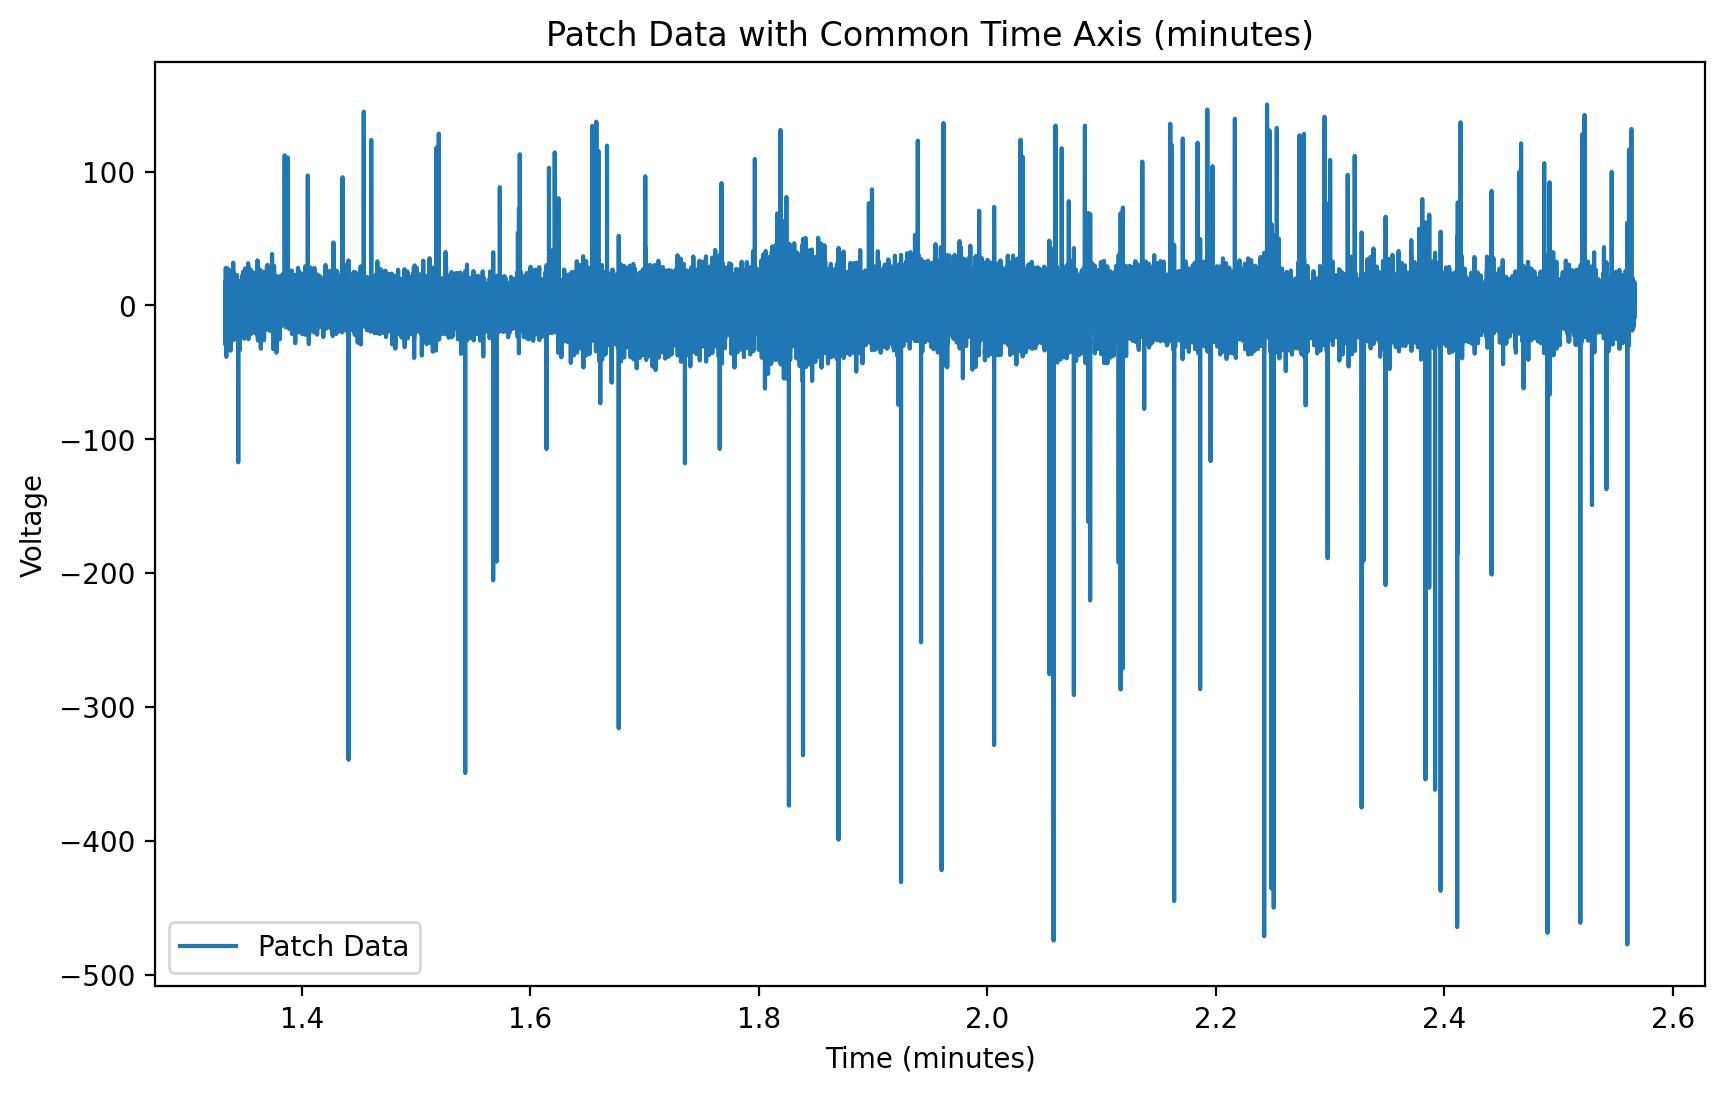

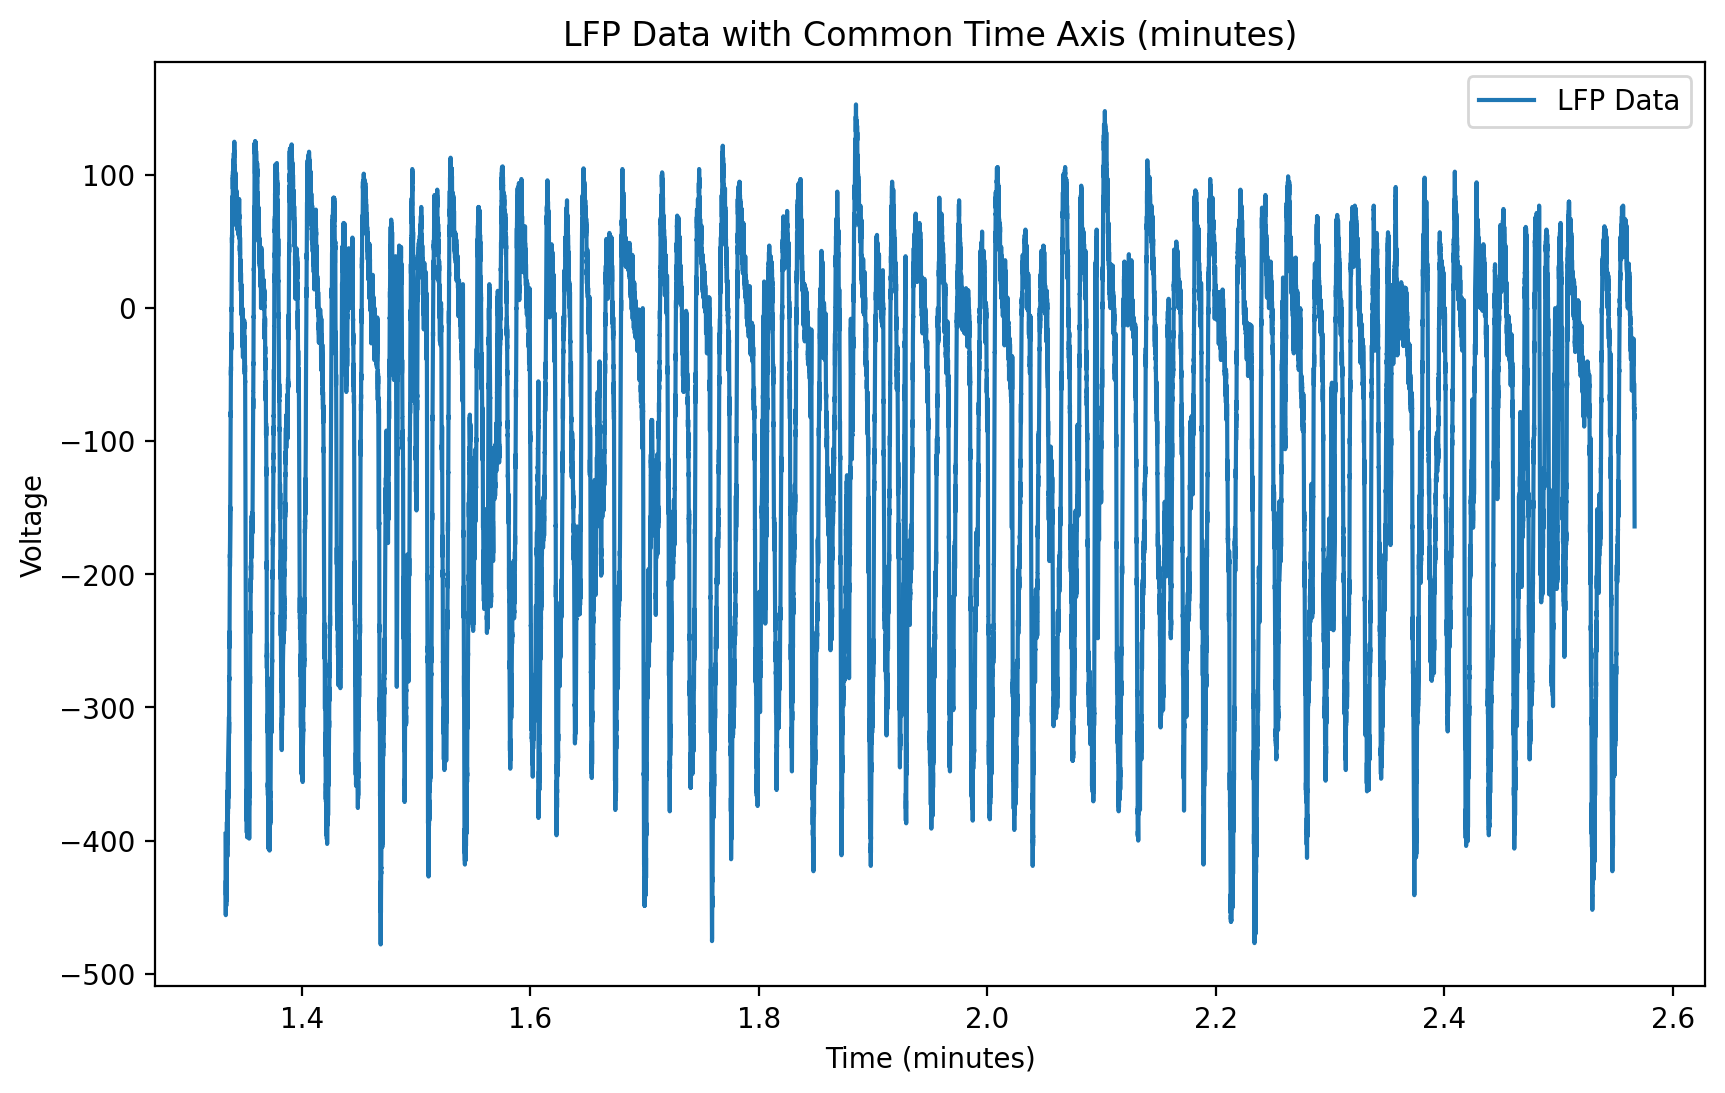

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

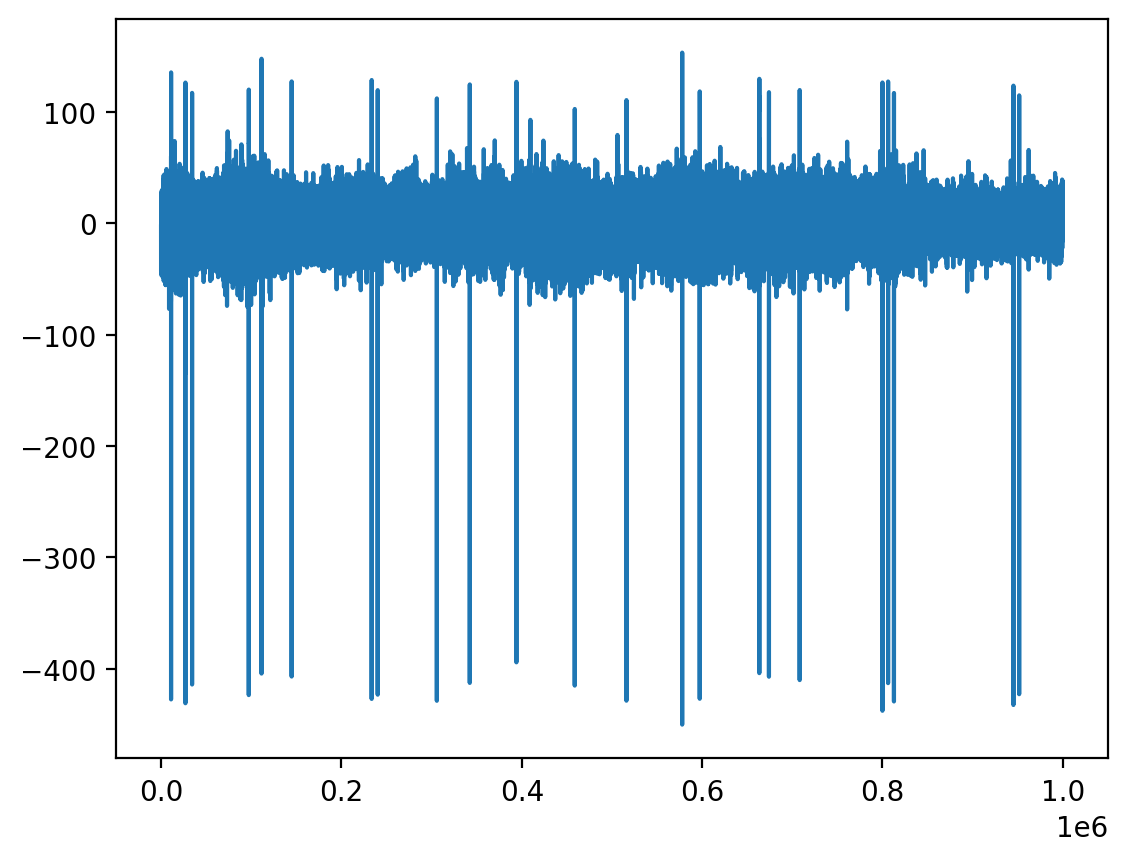

In [7]:
plt.plot(patch_filt[:1000000] )

In [8]:



#threshold in mVs
sp = Spike(thresh_amp=100, window_length=(5., 5.), smooth_frac=.01)

In [9]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/3130 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/numpy-1.24.1-py3.9-macosx-10.9-x86_64.egg/numpy/lib/function_base.py:2855: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


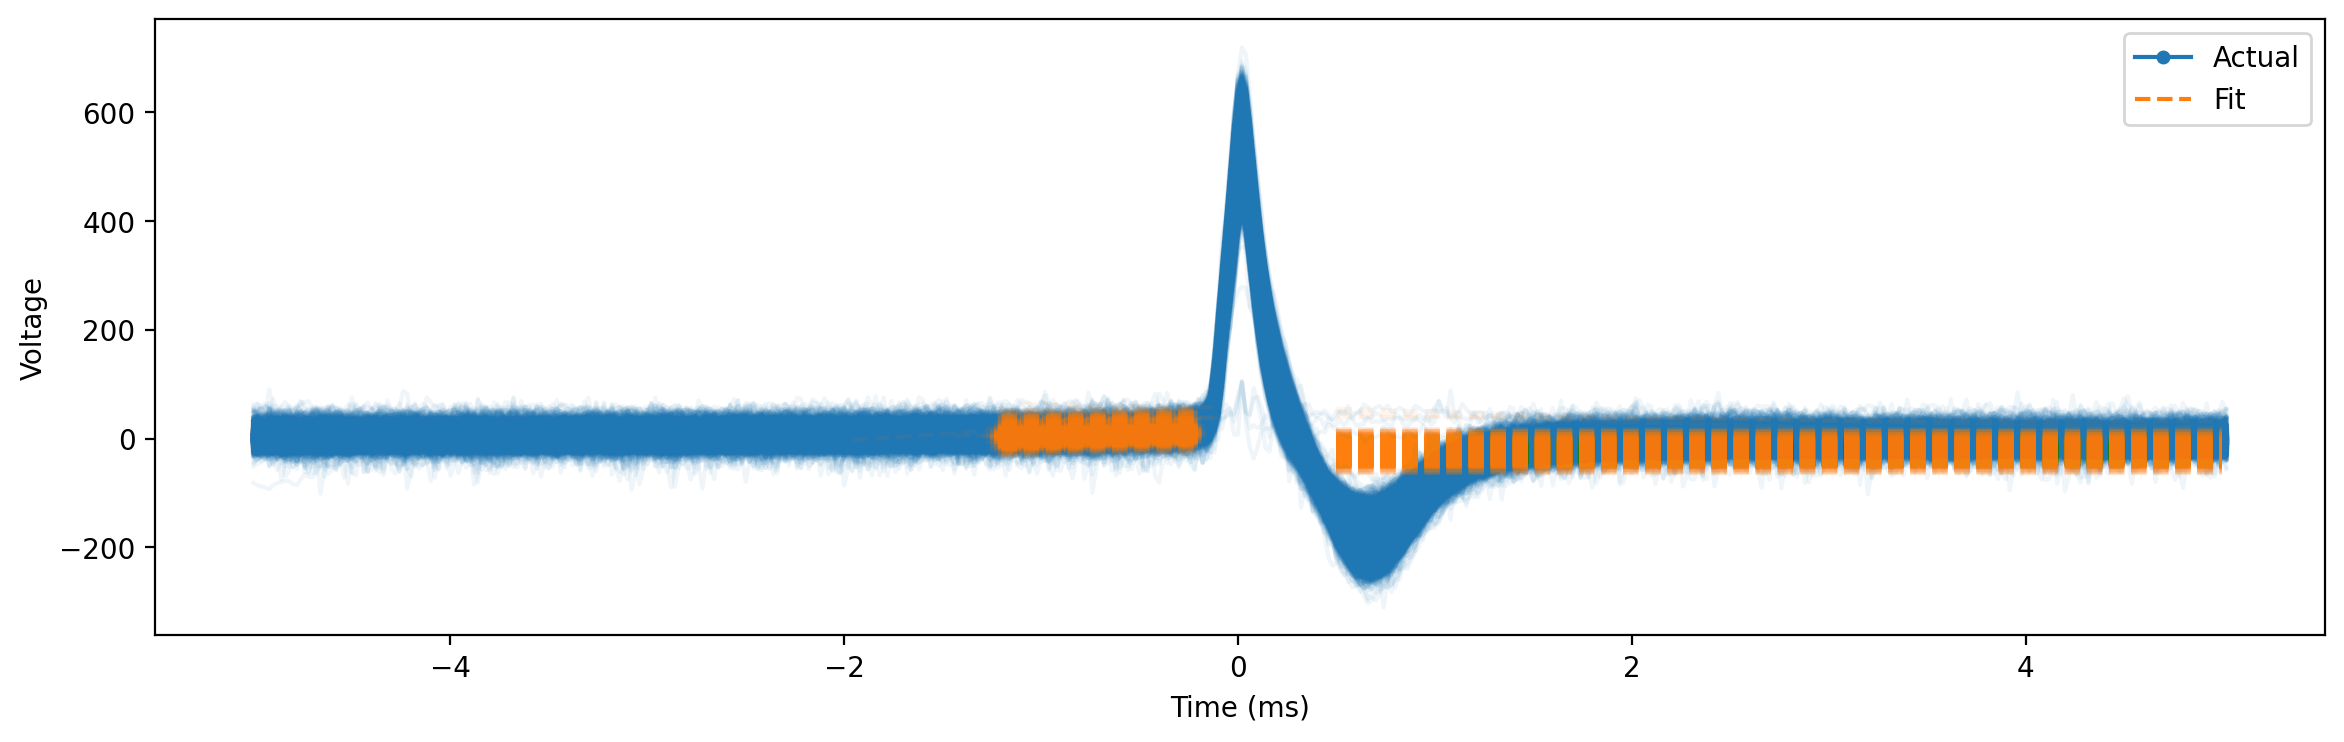

In [10]:
sp.plot()

### Filter spikes 

In [11]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [12]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [13]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,11.438337,0.16,9.399019,375.013784,0.16,235.947397,0.000007,-9.807769,2.502602,11121,222.313806,0
1,18.221075,0.14,21.019411,396.359088,0.16,261.166383,0.000002,-12.109163,2.169291,27035,540.441844,1
2,-5.359112,0.18,9.578360,406.302808,0.16,262.609902,0.000010,-12.884498,3.099204,34422,688.111306,2
3,-6.407286,0.18,-21.983262,363.832160,0.18,216.443678,0.000012,-15.682209,2.450780,97283,1944.731050,3
4,2.212759,0.18,-2.899837,367.547845,0.16,233.958407,0.000005,-28.229646,2.824660,111407,2227.076181,4
...,...,...,...,...,...,...,...,...,...,...,...,...
3125,2.810489,0.22,9.458311,589.818818,0.20,311.005516,0.000027,-29.385983,2.767779,40468094,808975.452436,3119
3126,1.293358,0.22,0.510775,570.736758,0.20,315.522802,0.000045,-33.993934,2.307460,40497400,809561.292595,3120
3127,5.598719,0.20,16.874818,576.018090,0.20,300.906785,10.000000,-36.467981,2.126249,40507554,809764.275635,3121
3128,-3.454853,0.20,18.652984,591.401420,0.20,313.241141,0.000027,-32.315256,1.886509,40514244,809898.011752,3122


### Get spike times


In [14]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [15]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi',
       'spk_times_idx', 'spk_times_ms', 'spk_id'],
      dtype='object')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


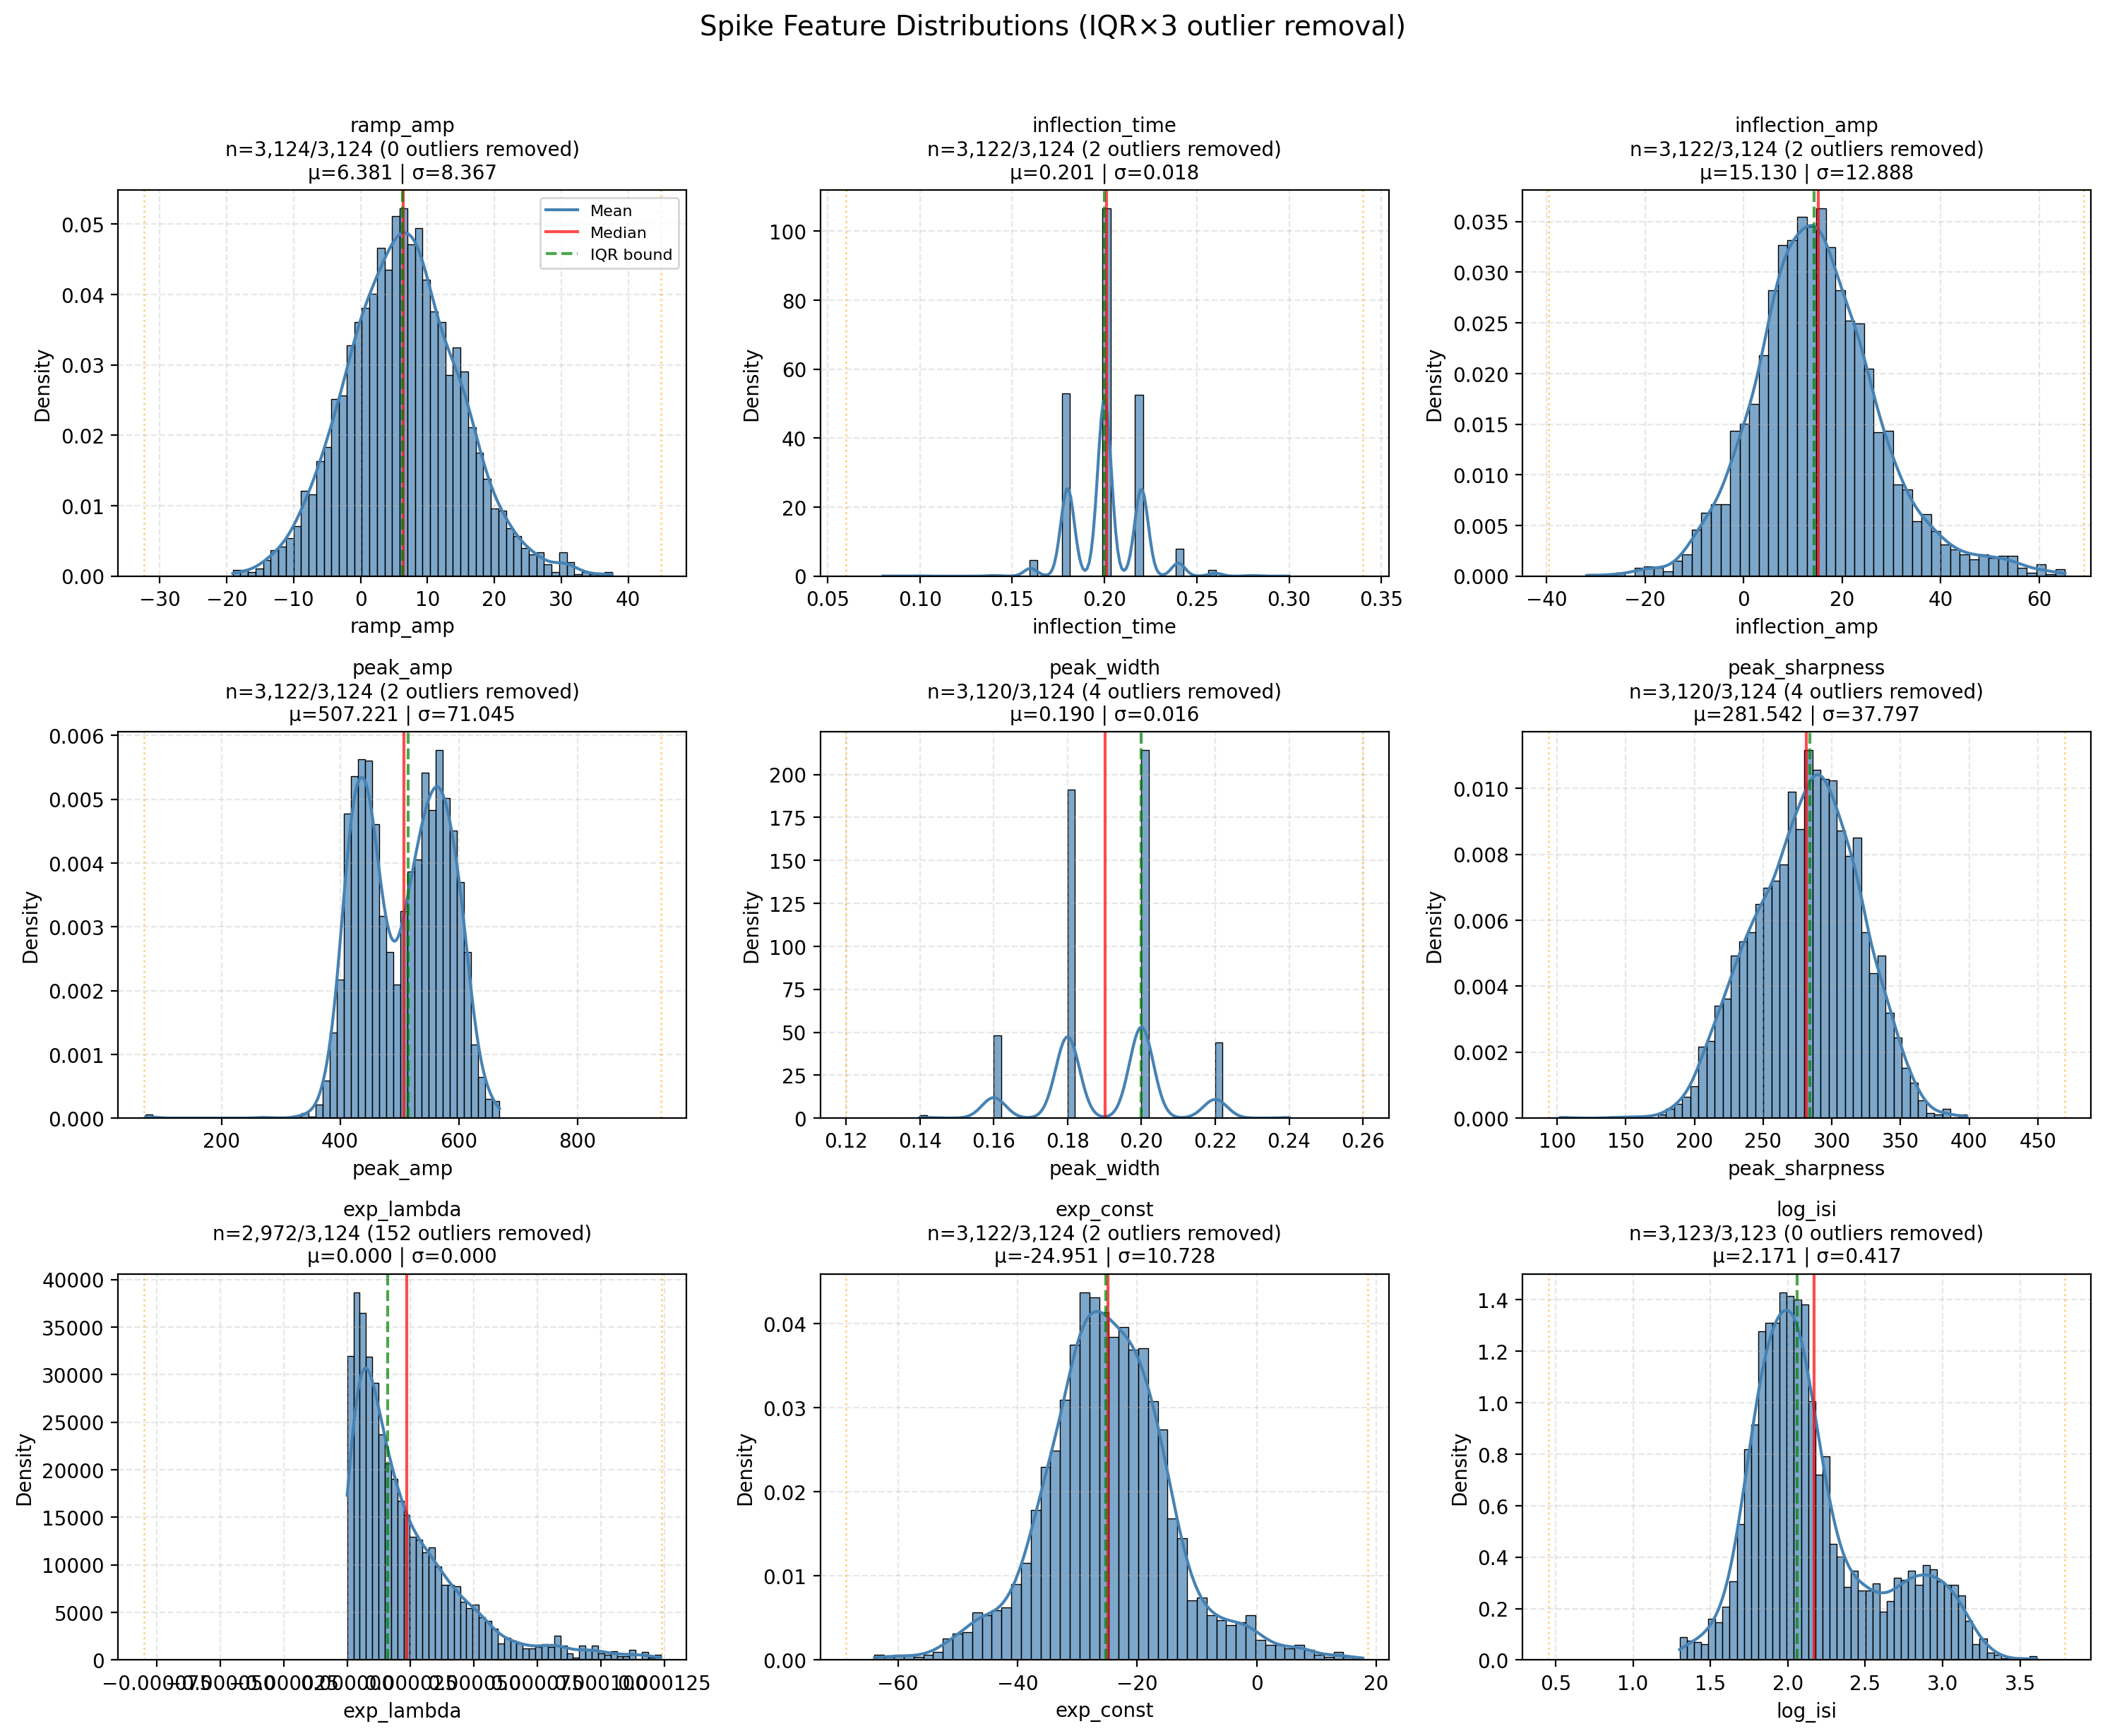


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             3124       3124       0          0.0        6.381      8.367     
inflection_time      3124       3122       2          0.1        0.201      0.018     
inflection_amp       3124       3122       2          0.1        15.130     12.888    
peak_amp             3124       3122       2          0.1        507.221    71.045    
peak_width           3124       3120       4          0.1        0.190      0.016     
peak_sharpness       3124       3120       4          0.1        281.542    37.797    
exp_lambda           3124       2972       152        4.9        0.000      0.000     
exp_const            3124       3122       2          0.1        -24.951    10.728    
log_isi              3123       3123       0          0.0        2.171      0.417     


In [16]:
plot_spike_feature_distributions(df_features)

ramp_amp: Skipped - k_suggest = 1
inflection_time: Skipped - k_suggest = 1
inflection_amp: Skipped - k_suggest = 1


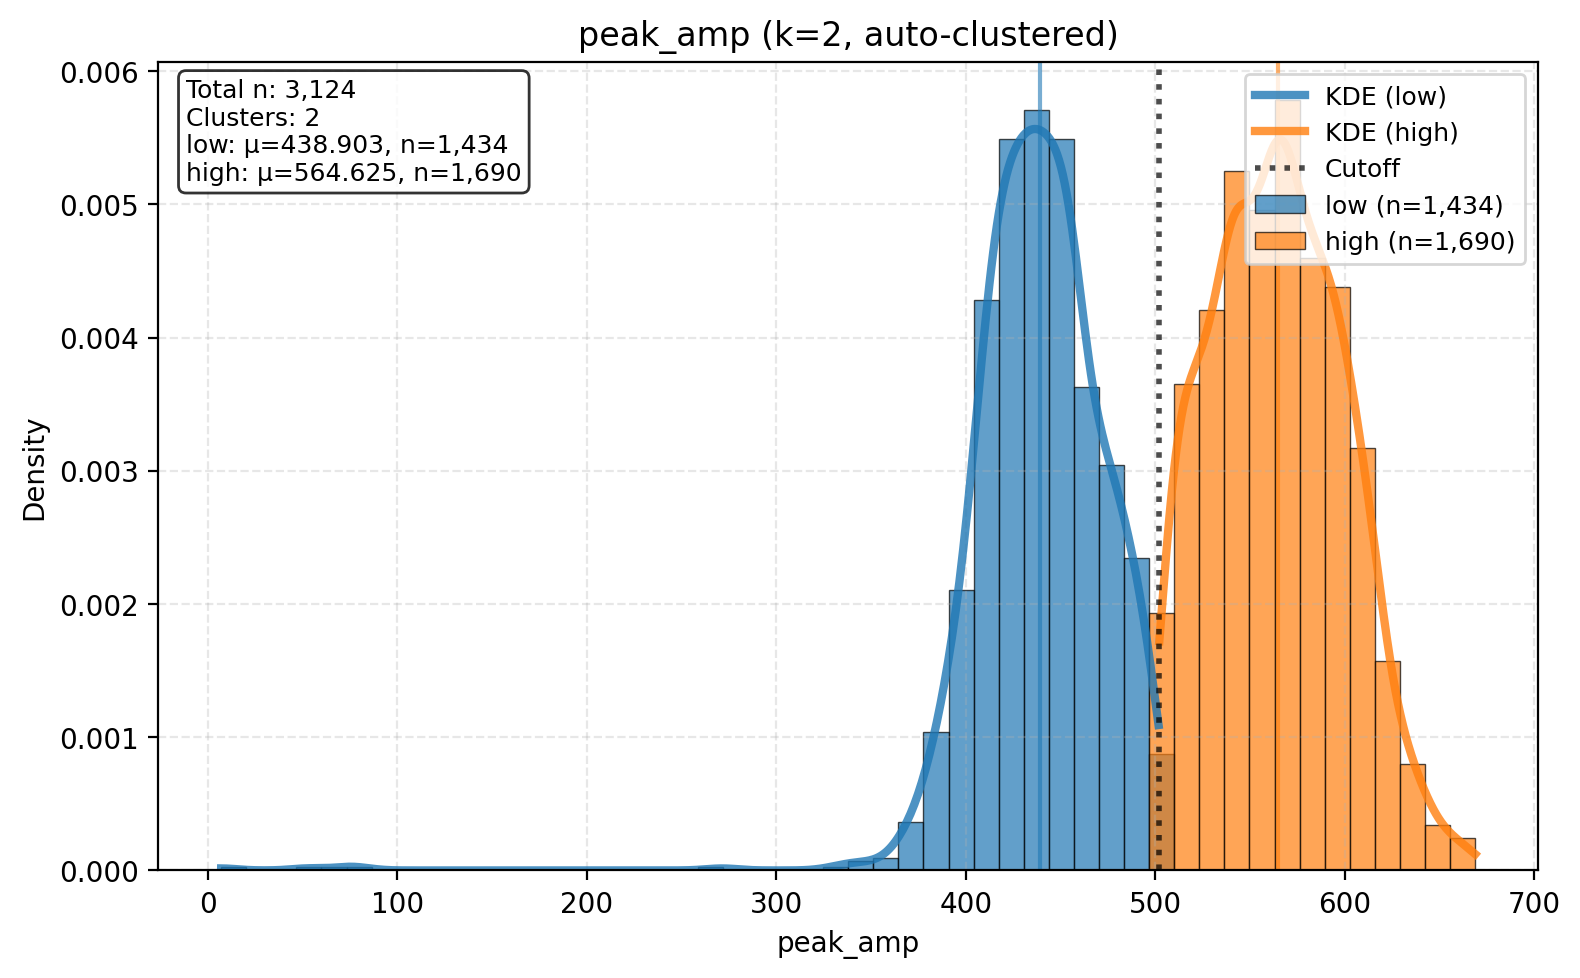

→ peak_width: Skipping (feature ignored).
peak_sharpness: Skipped - k_suggest = 1
exp_lambda: Skipped - k_suggest = 1
exp_const: Skipped - k_suggest = 1


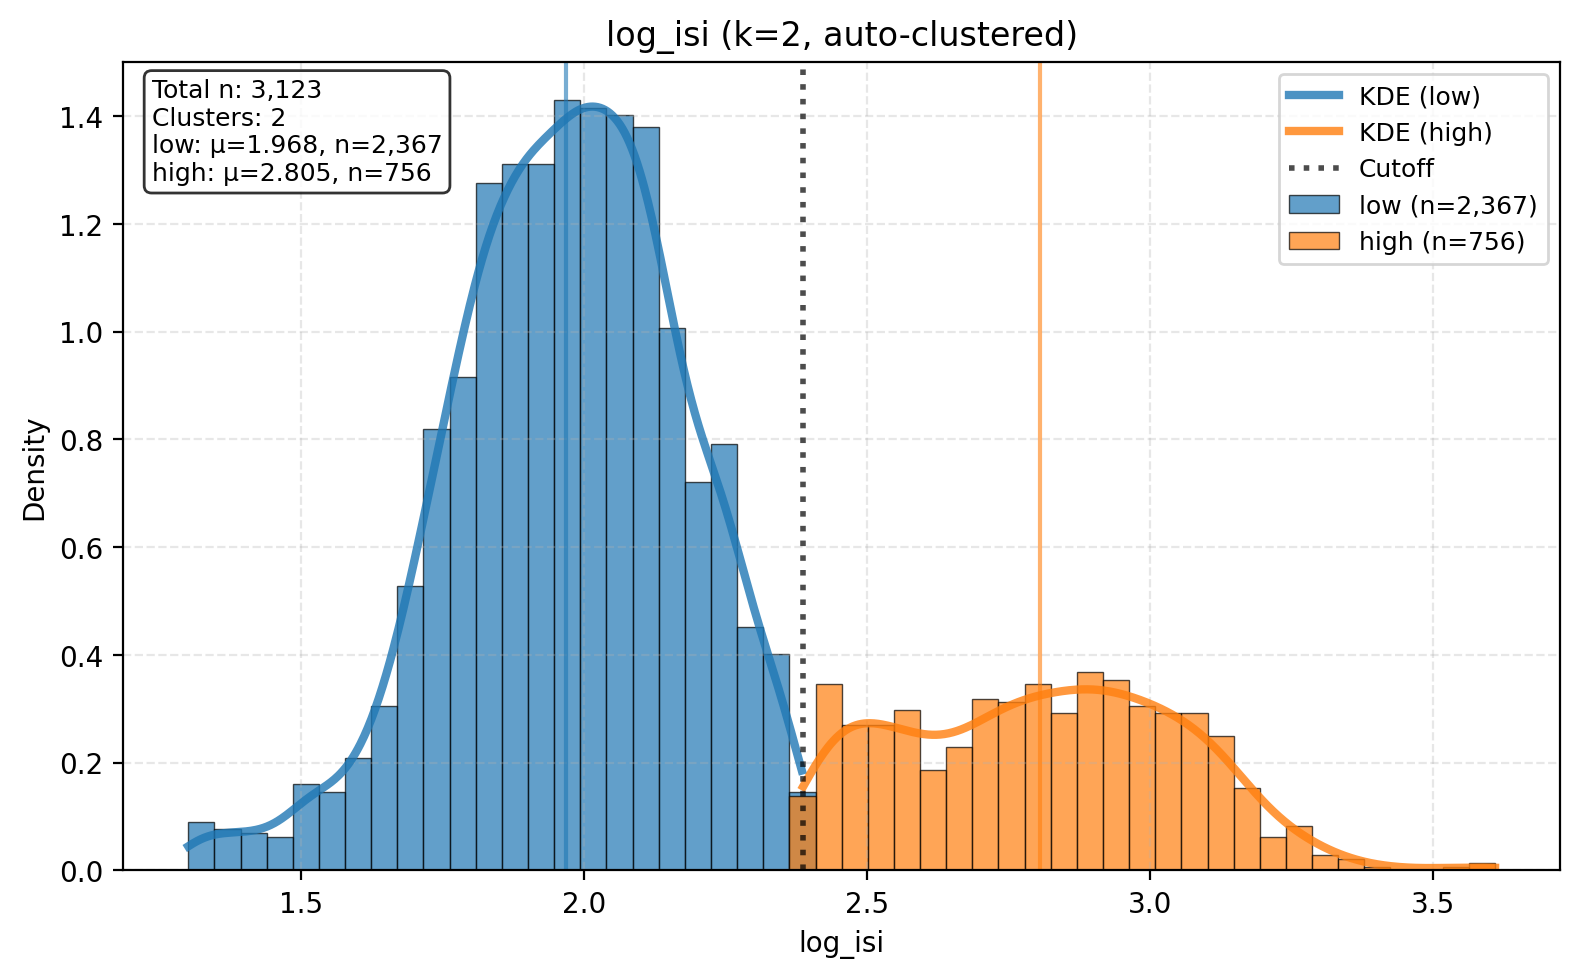

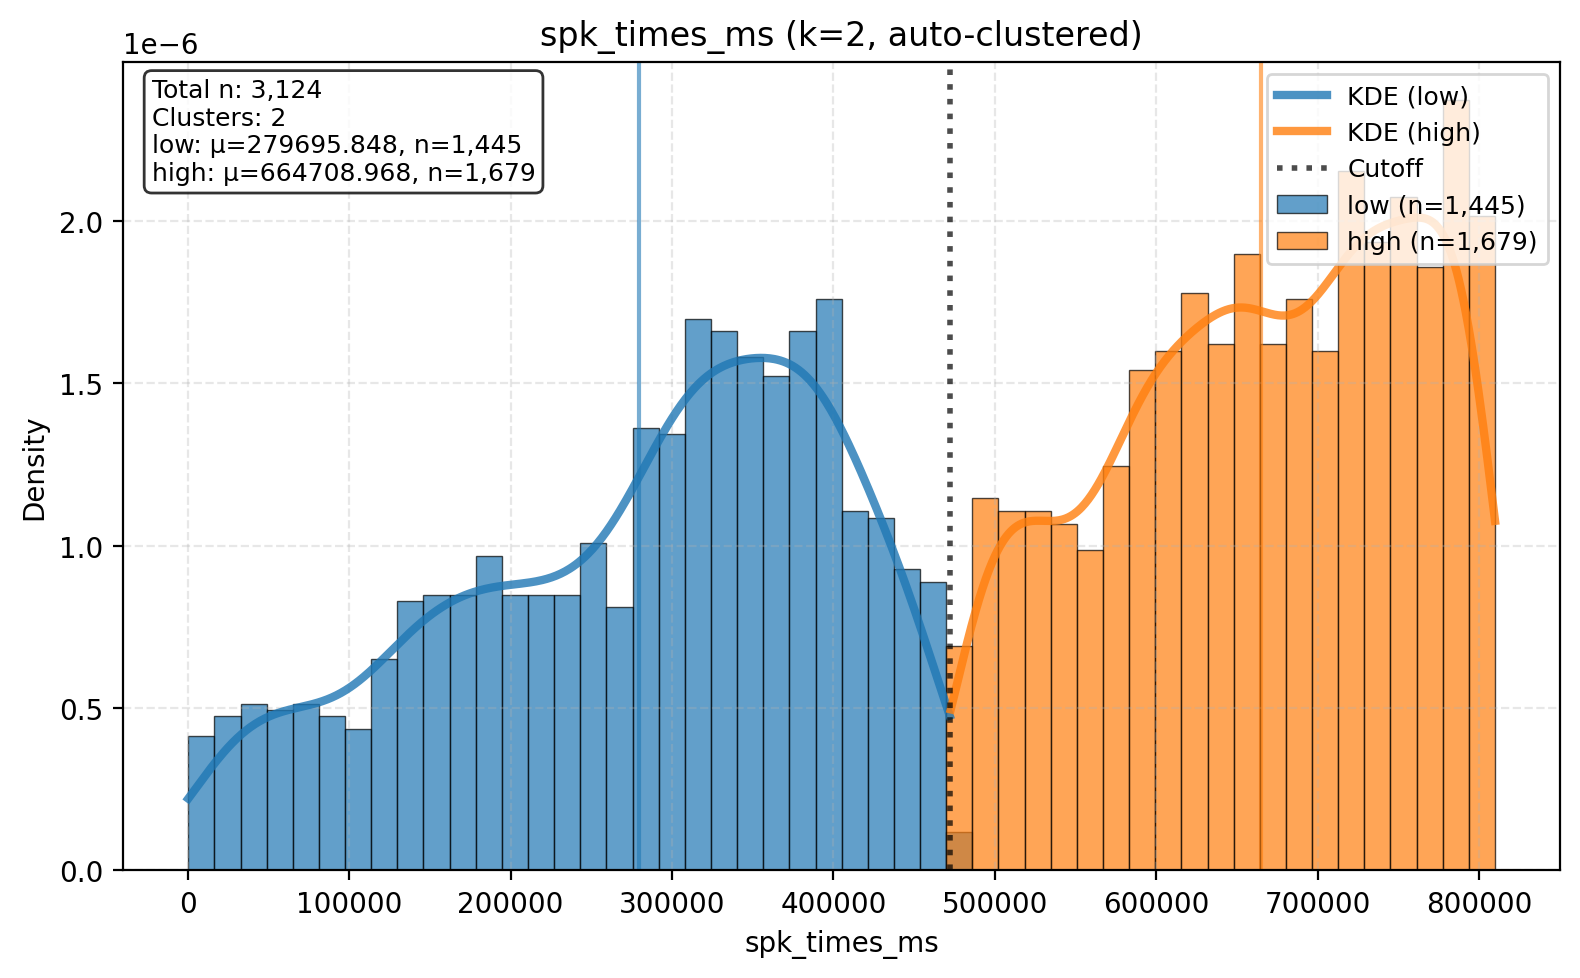

spk_id: Skipped - k_suggest = 1


In [19]:
# scan all numeric features and only cluster the ones that look multimodal
df_features_clust, rep = cluster_multimodal_features(
    df_features.drop("spk_times_idx", axis=1),
    max_k=2, ignore_features = "peak_width",
    suffix="_cluster",
    plot_each=True,  # set True if you want a quick plot per clustered feature, 
    manual_thresholds={
    }
)



===== CLUSTER REPORT: peak_amp_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


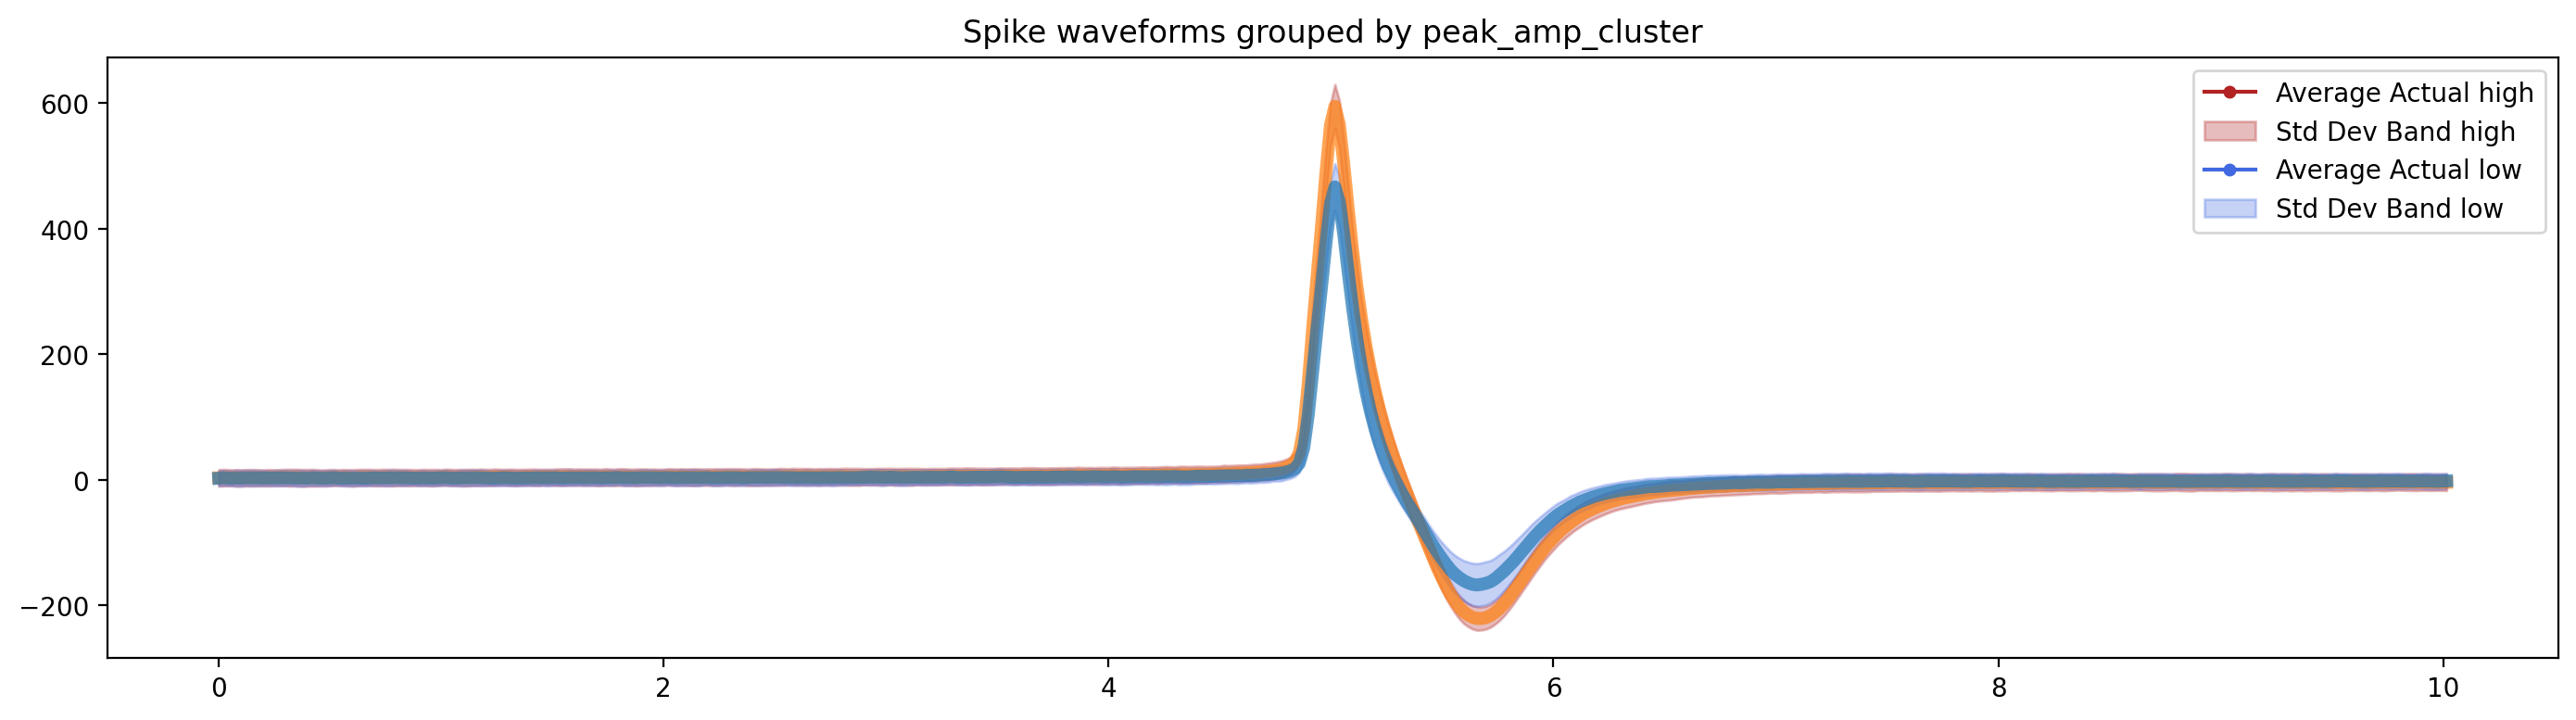

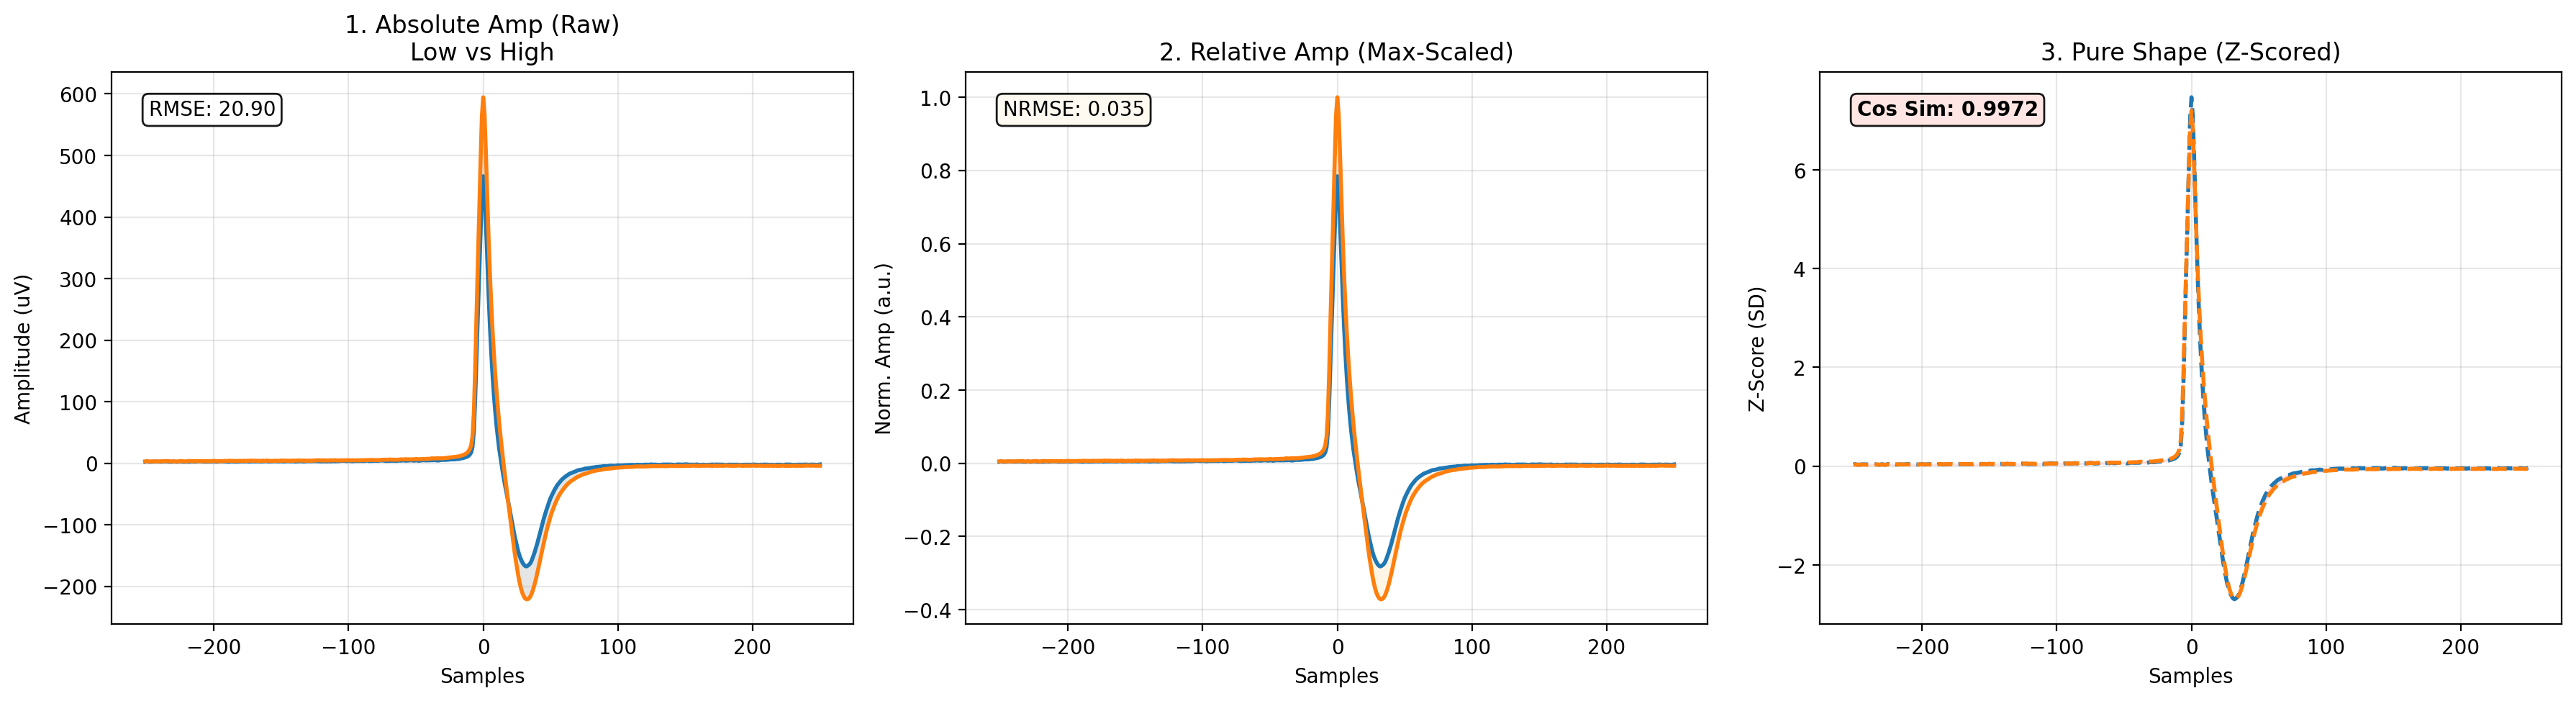


→ 2. Plotting cluster proportions over time


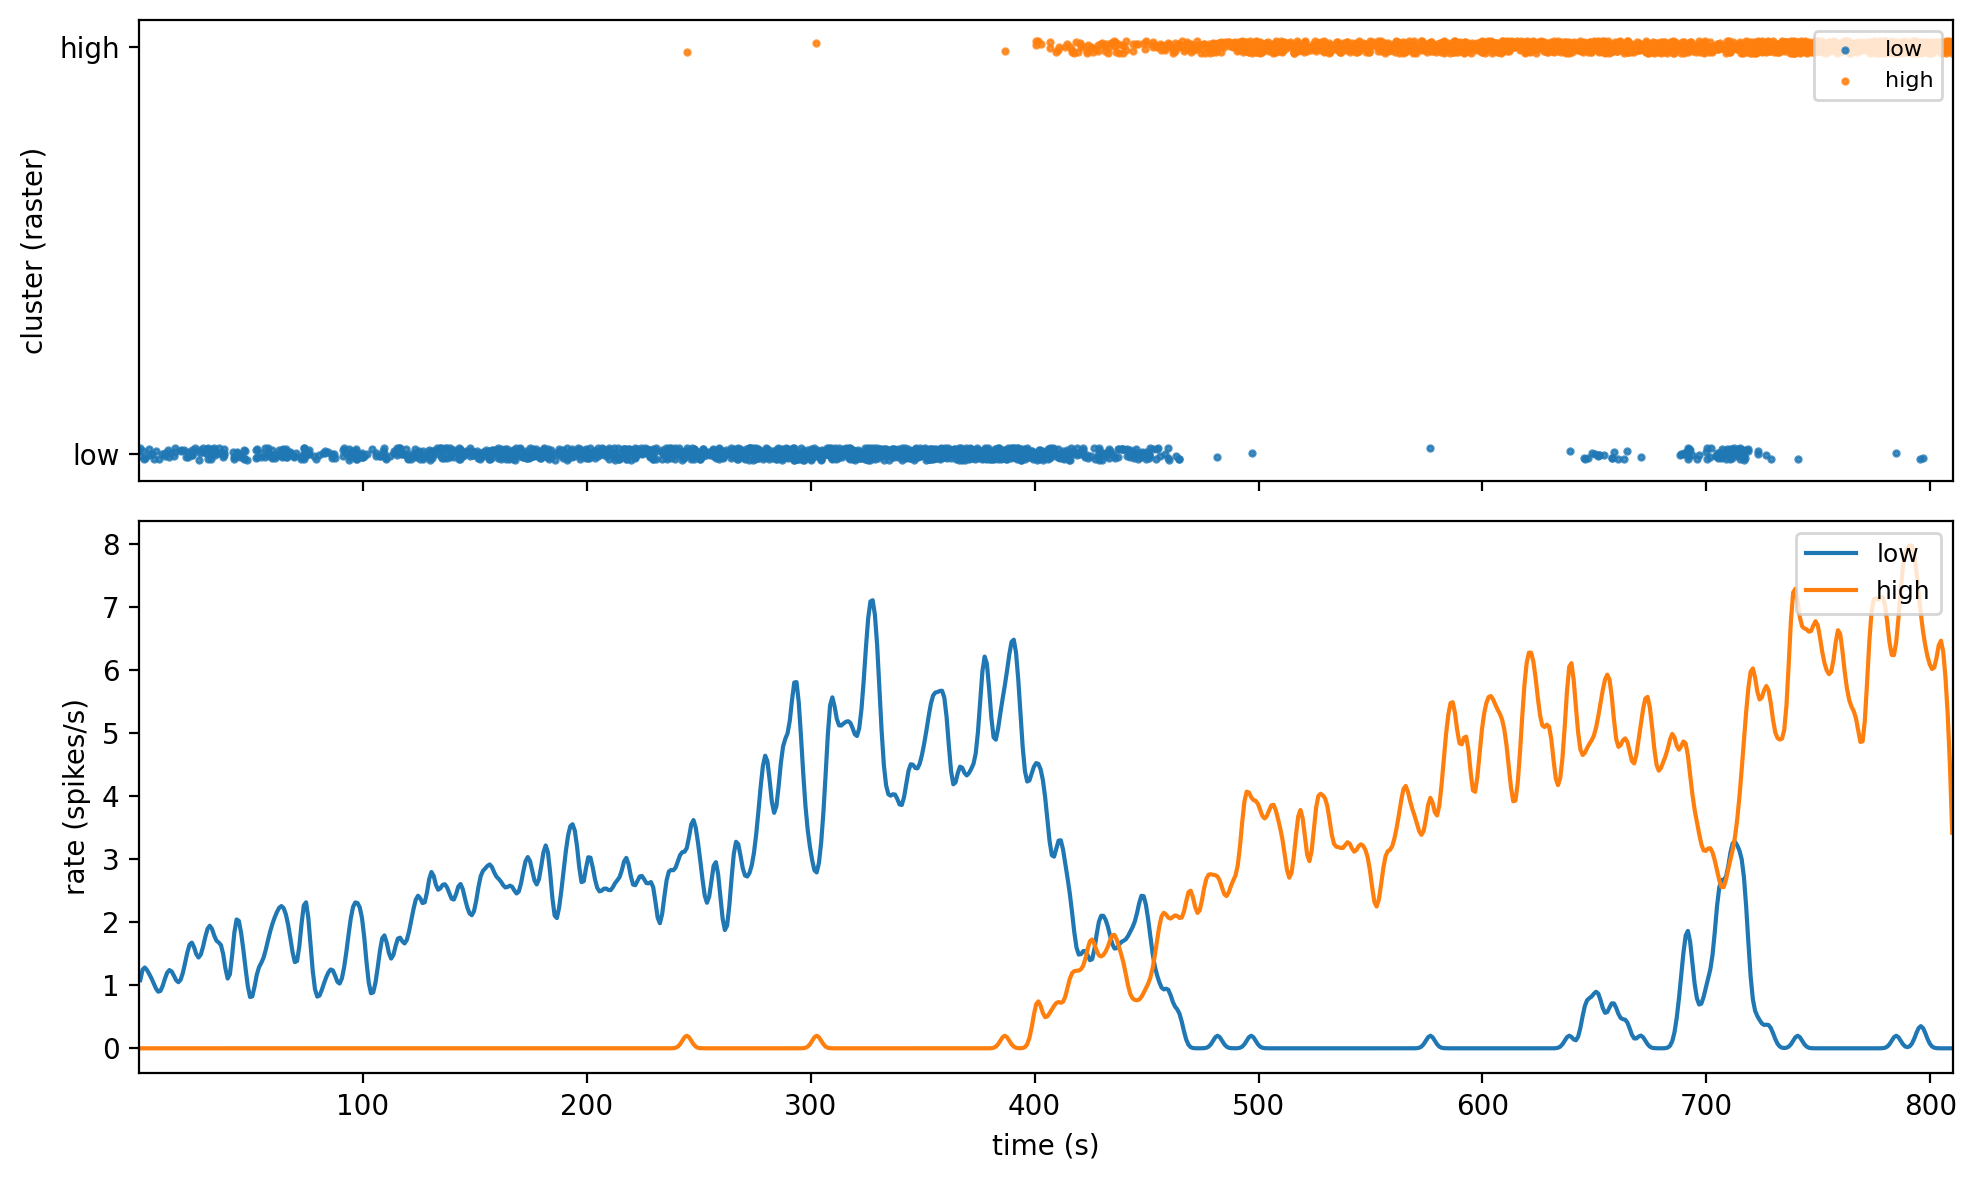


→ 3. Computing cluster transition matrix


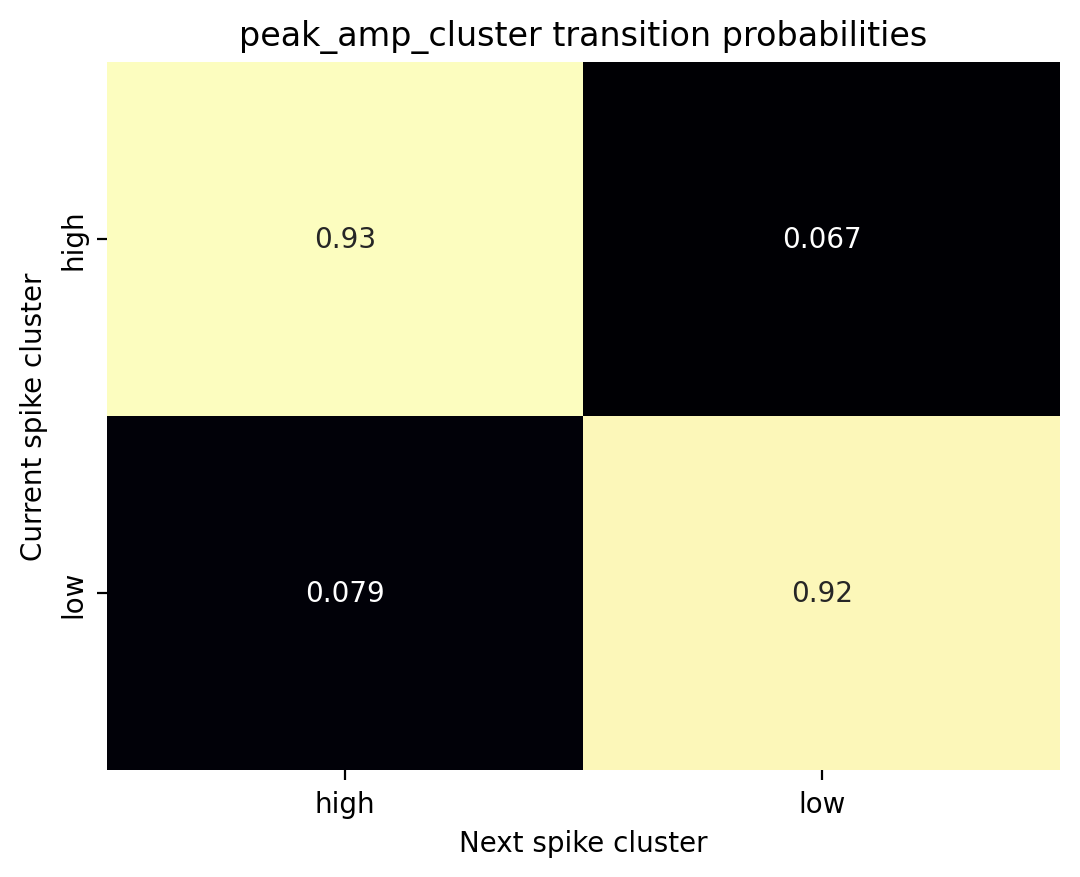


→ 4. Visualizing feature distributions by cluster


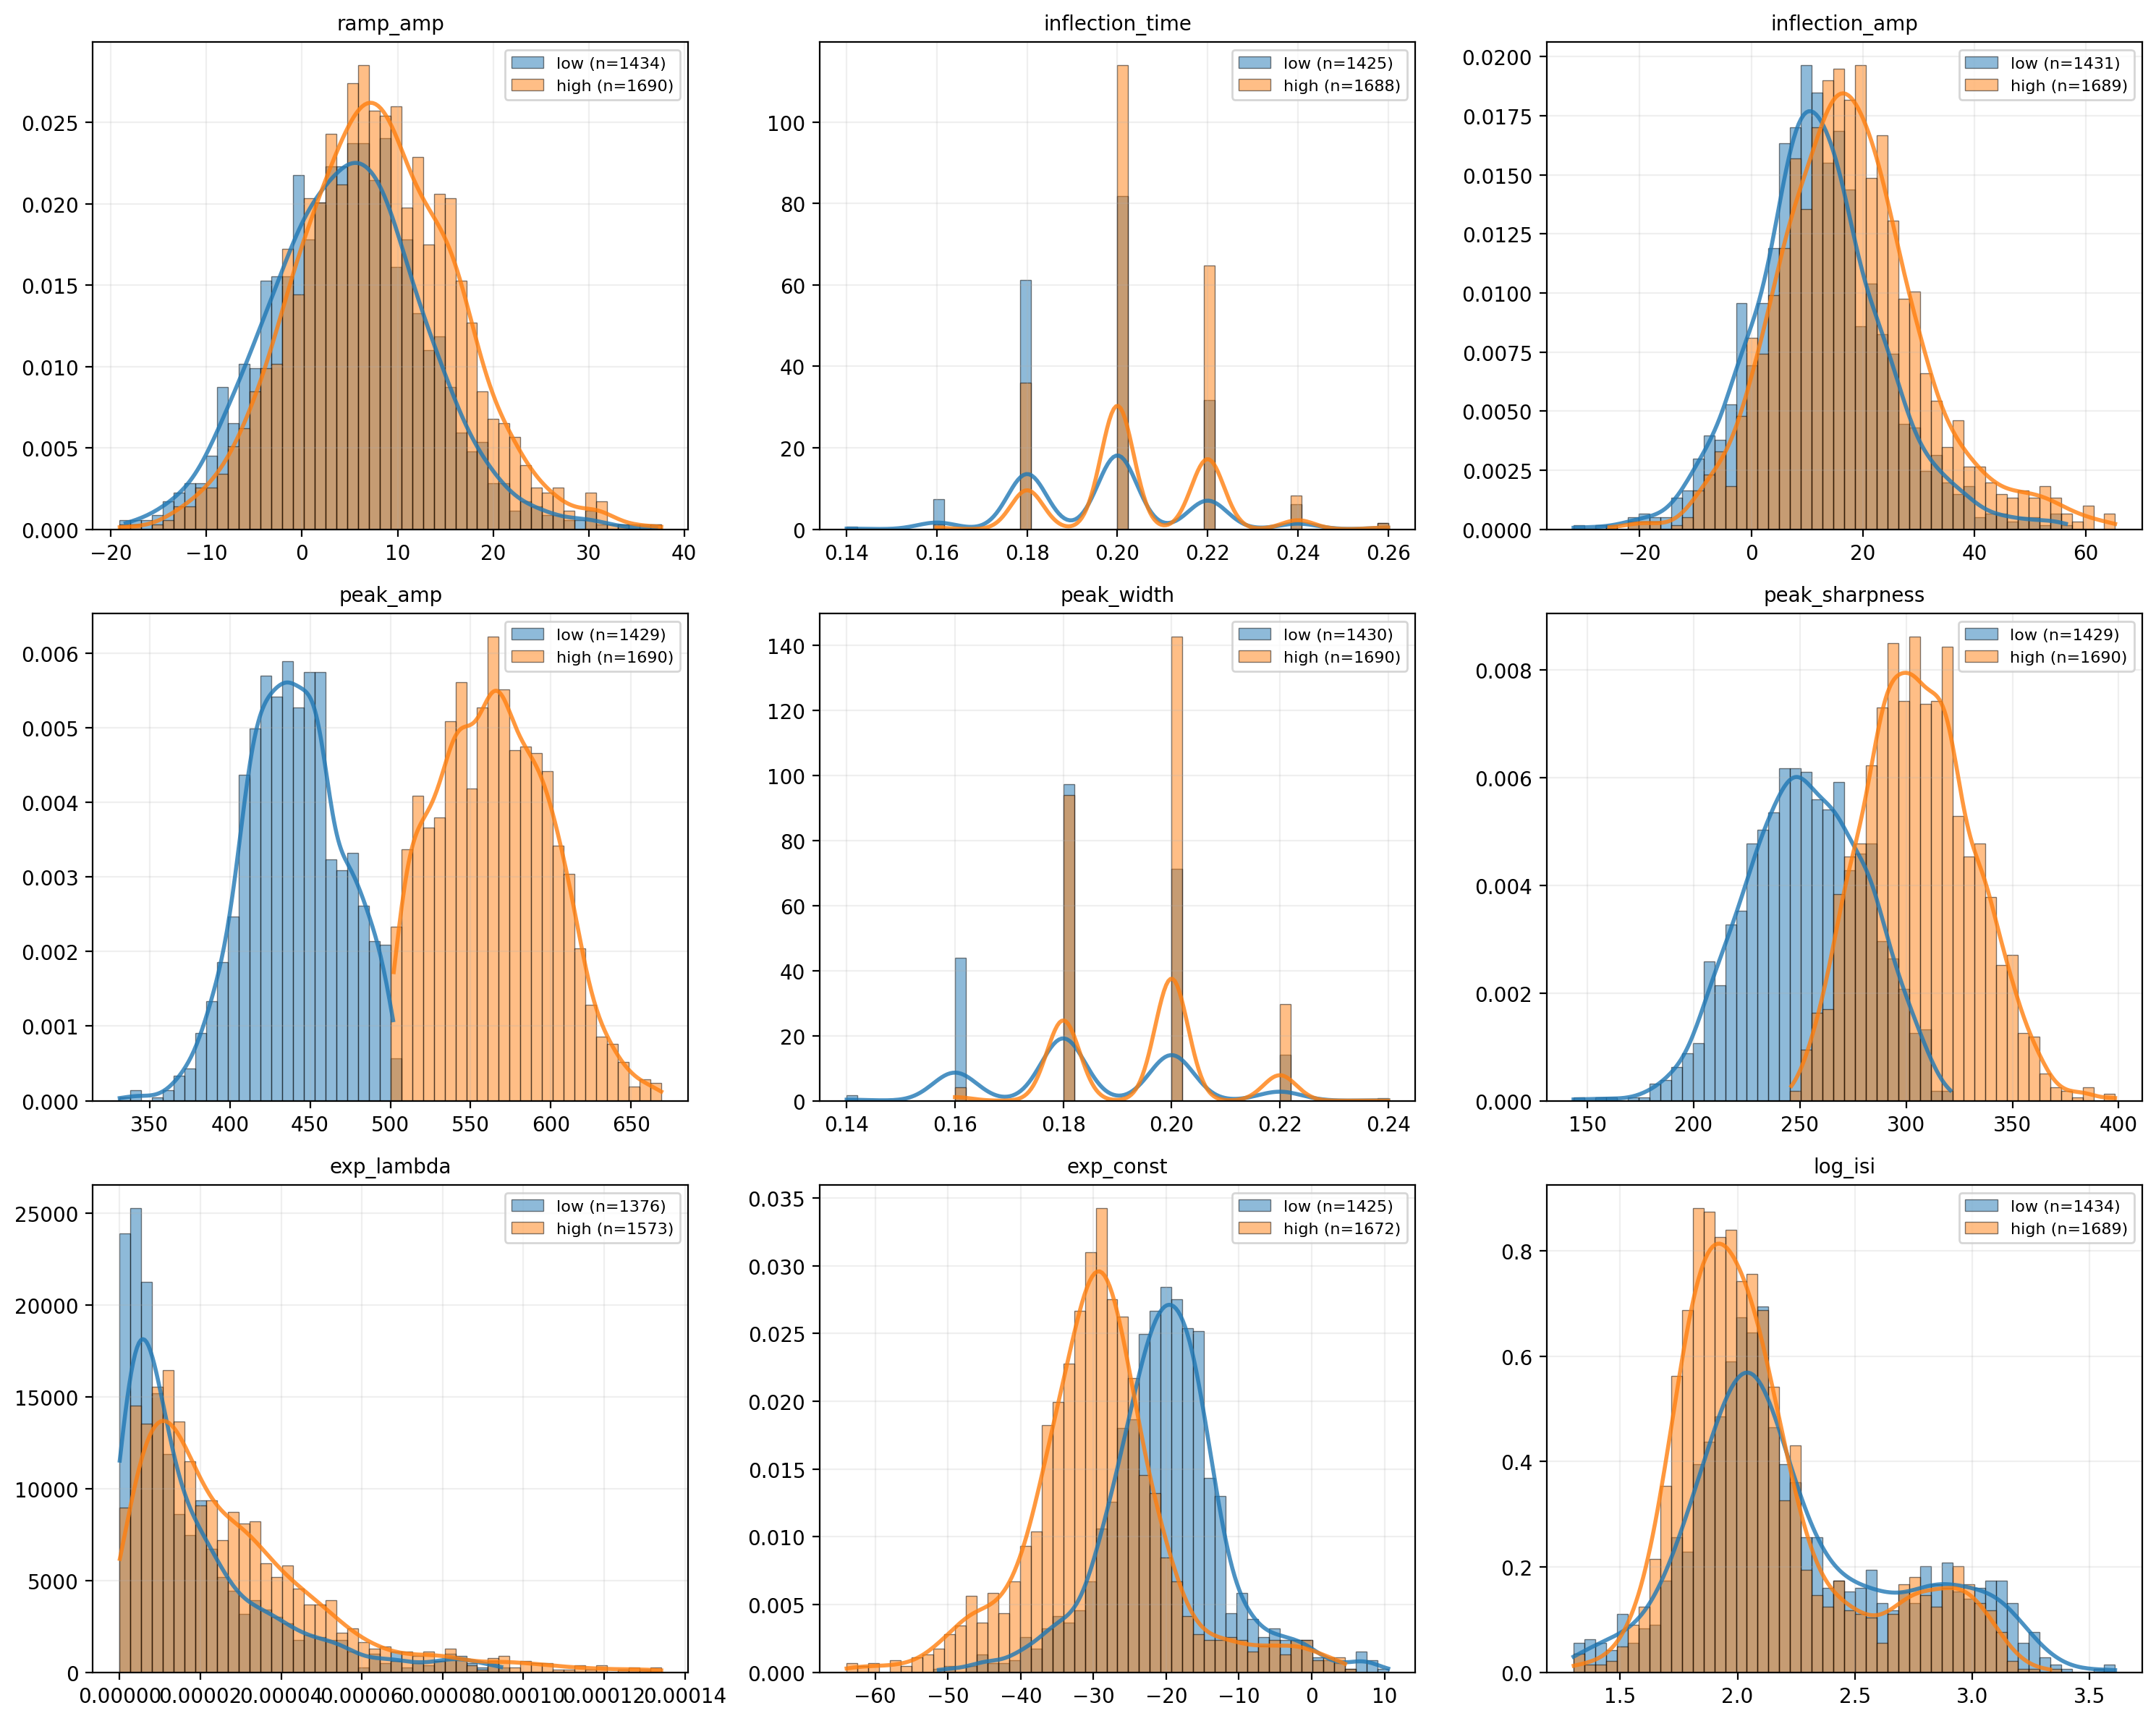


→ 5. Statistical analysis for: peak_amp
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.756
Interpretation: Very Large


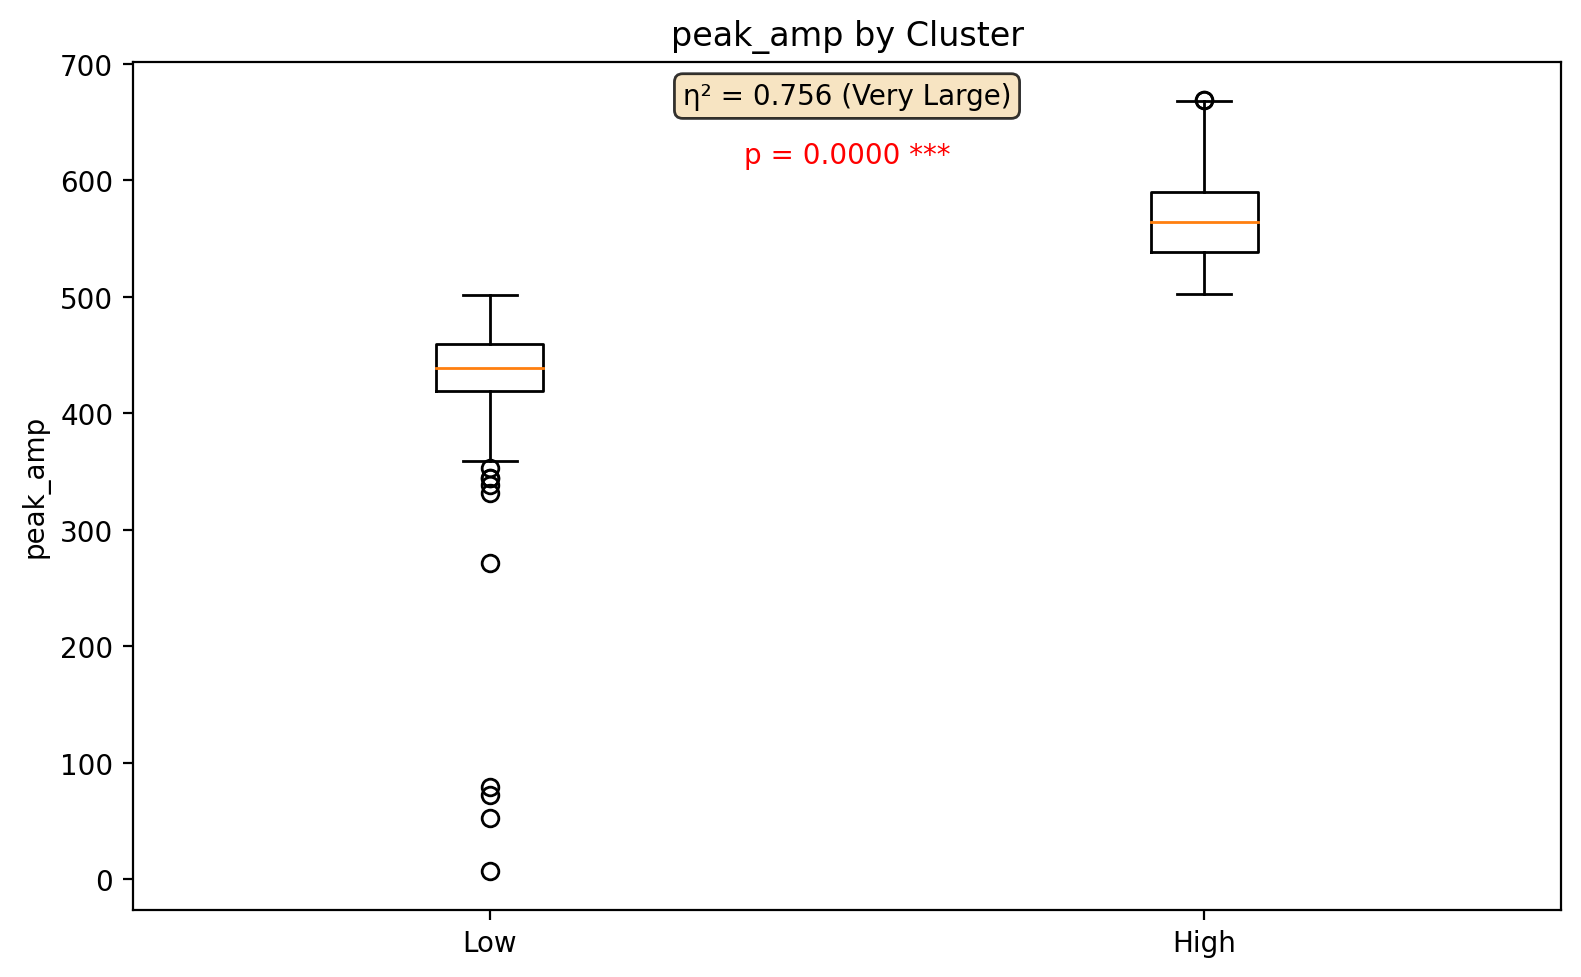


===== REPORT COMPLETE =====


===== CLUSTER REPORT: log_isi_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


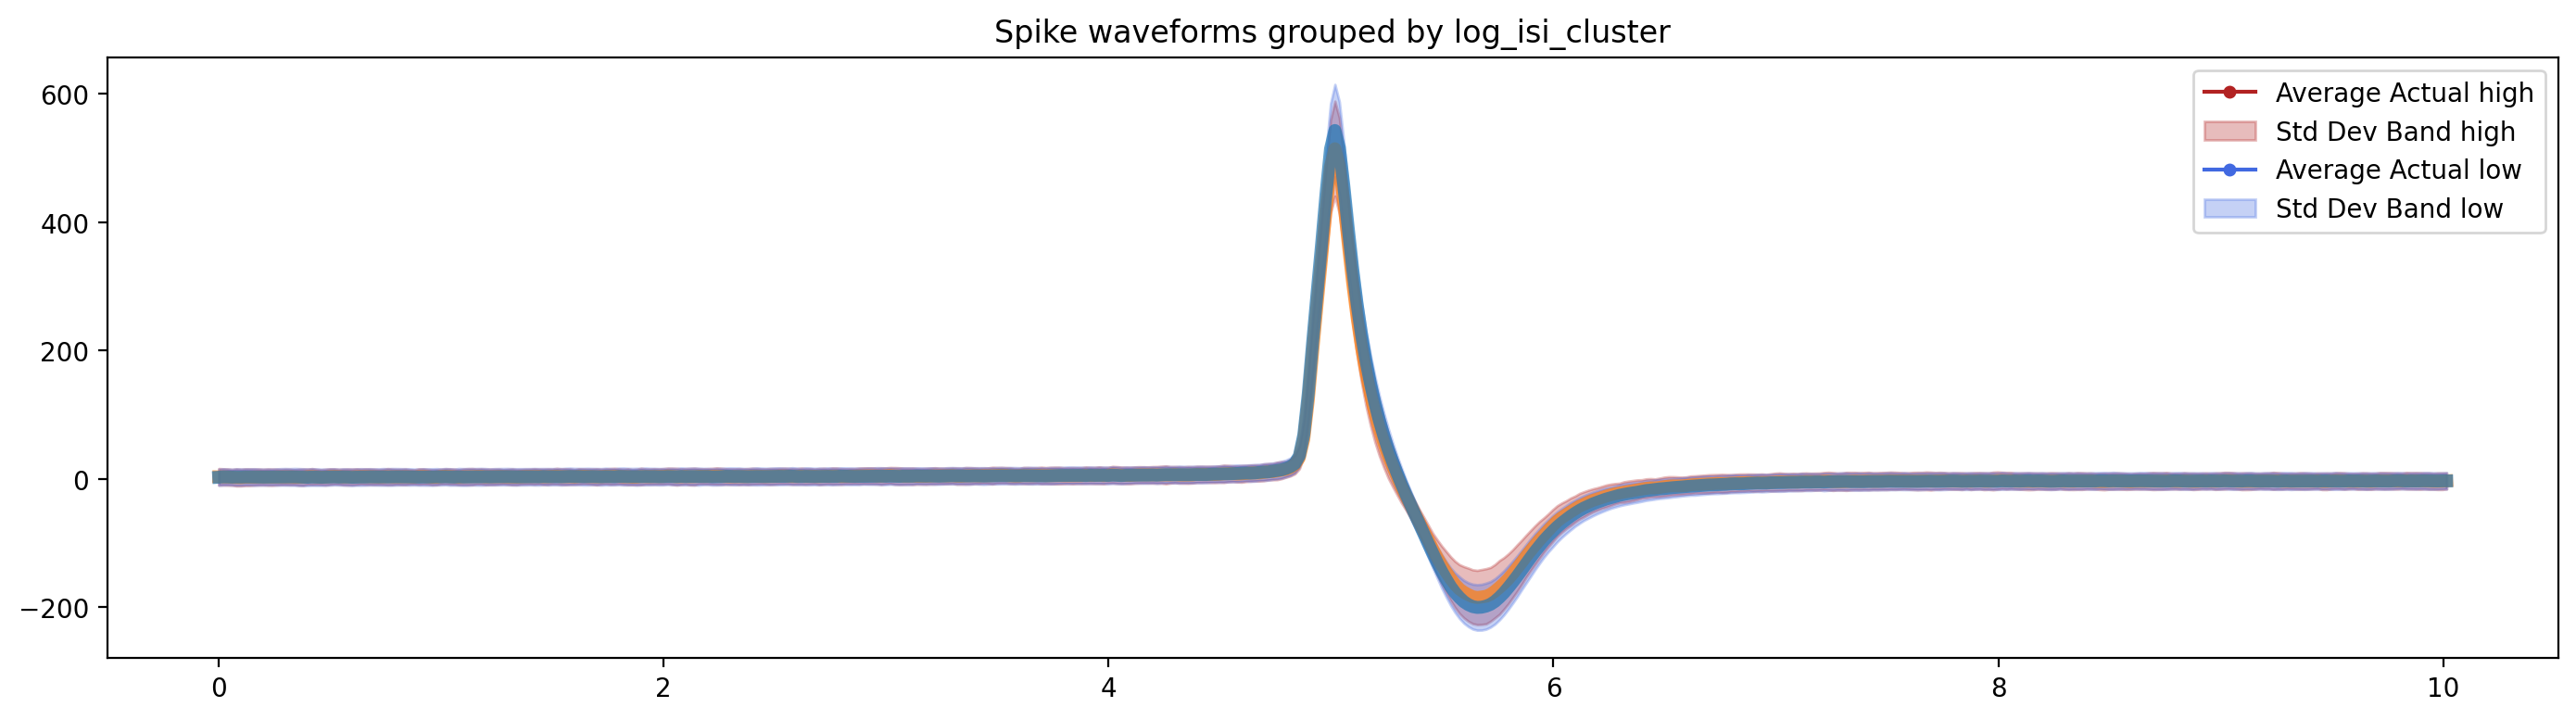

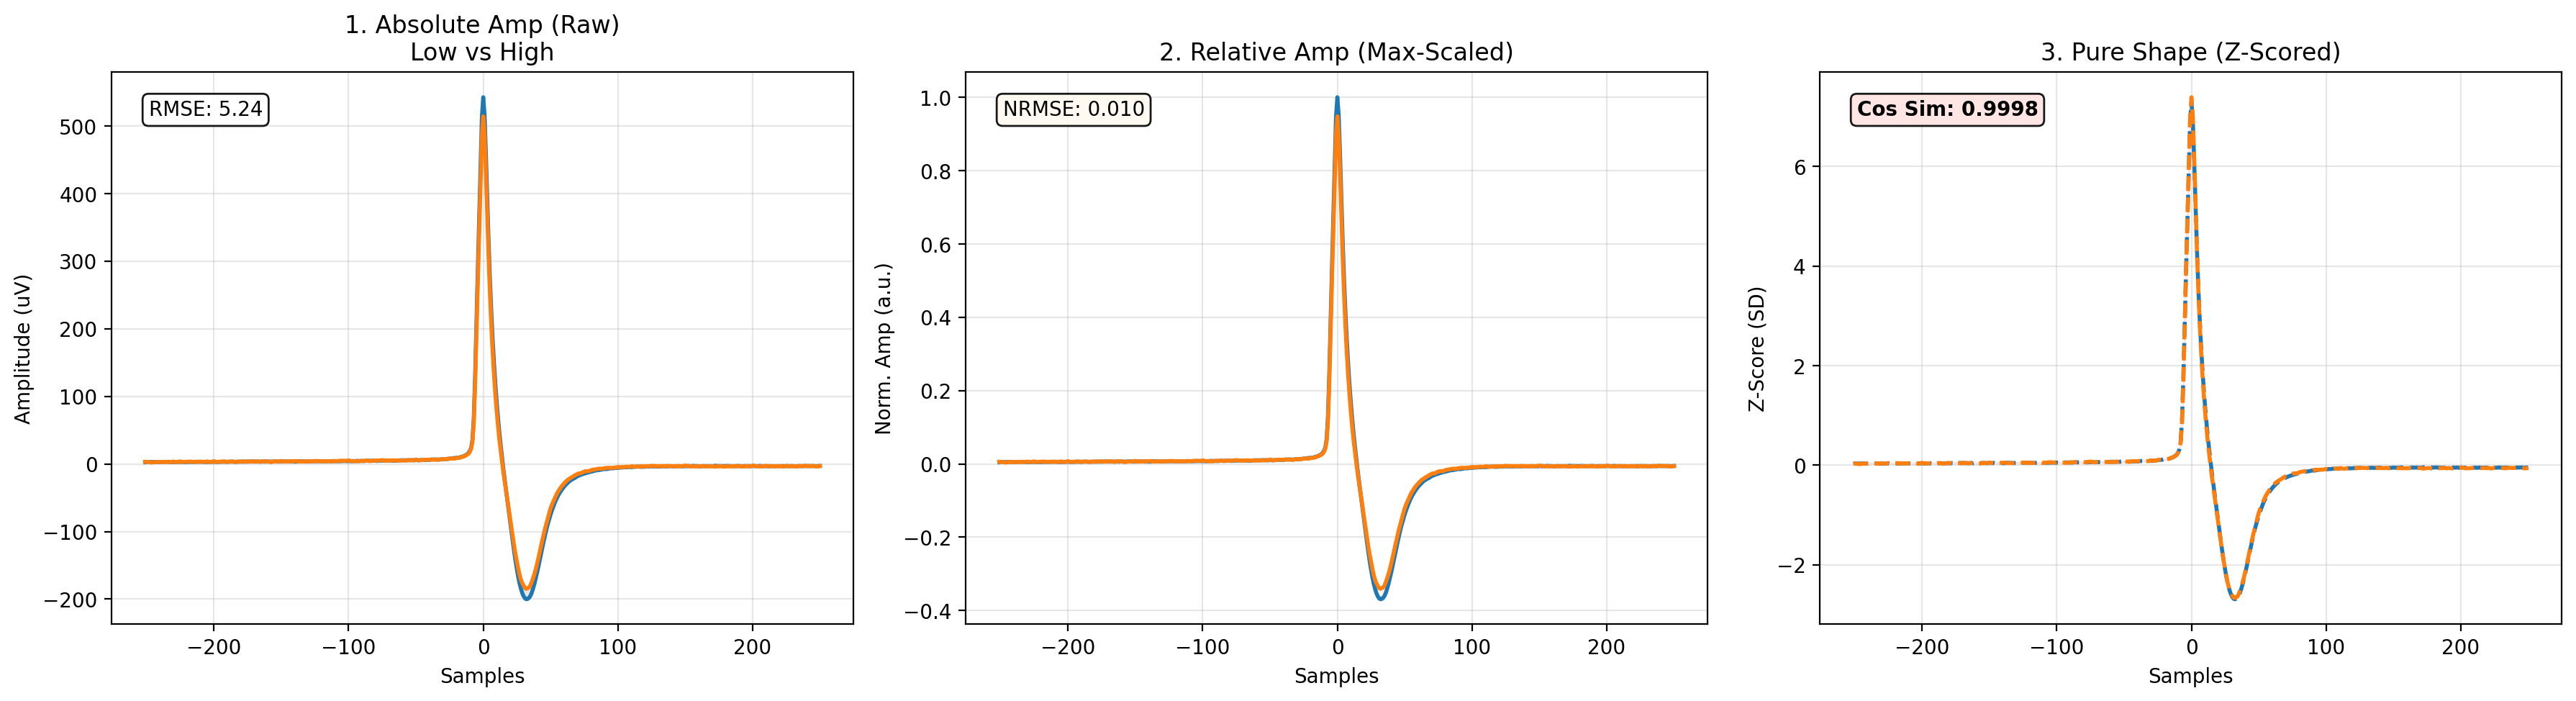


→ 2. Plotting cluster proportions over time


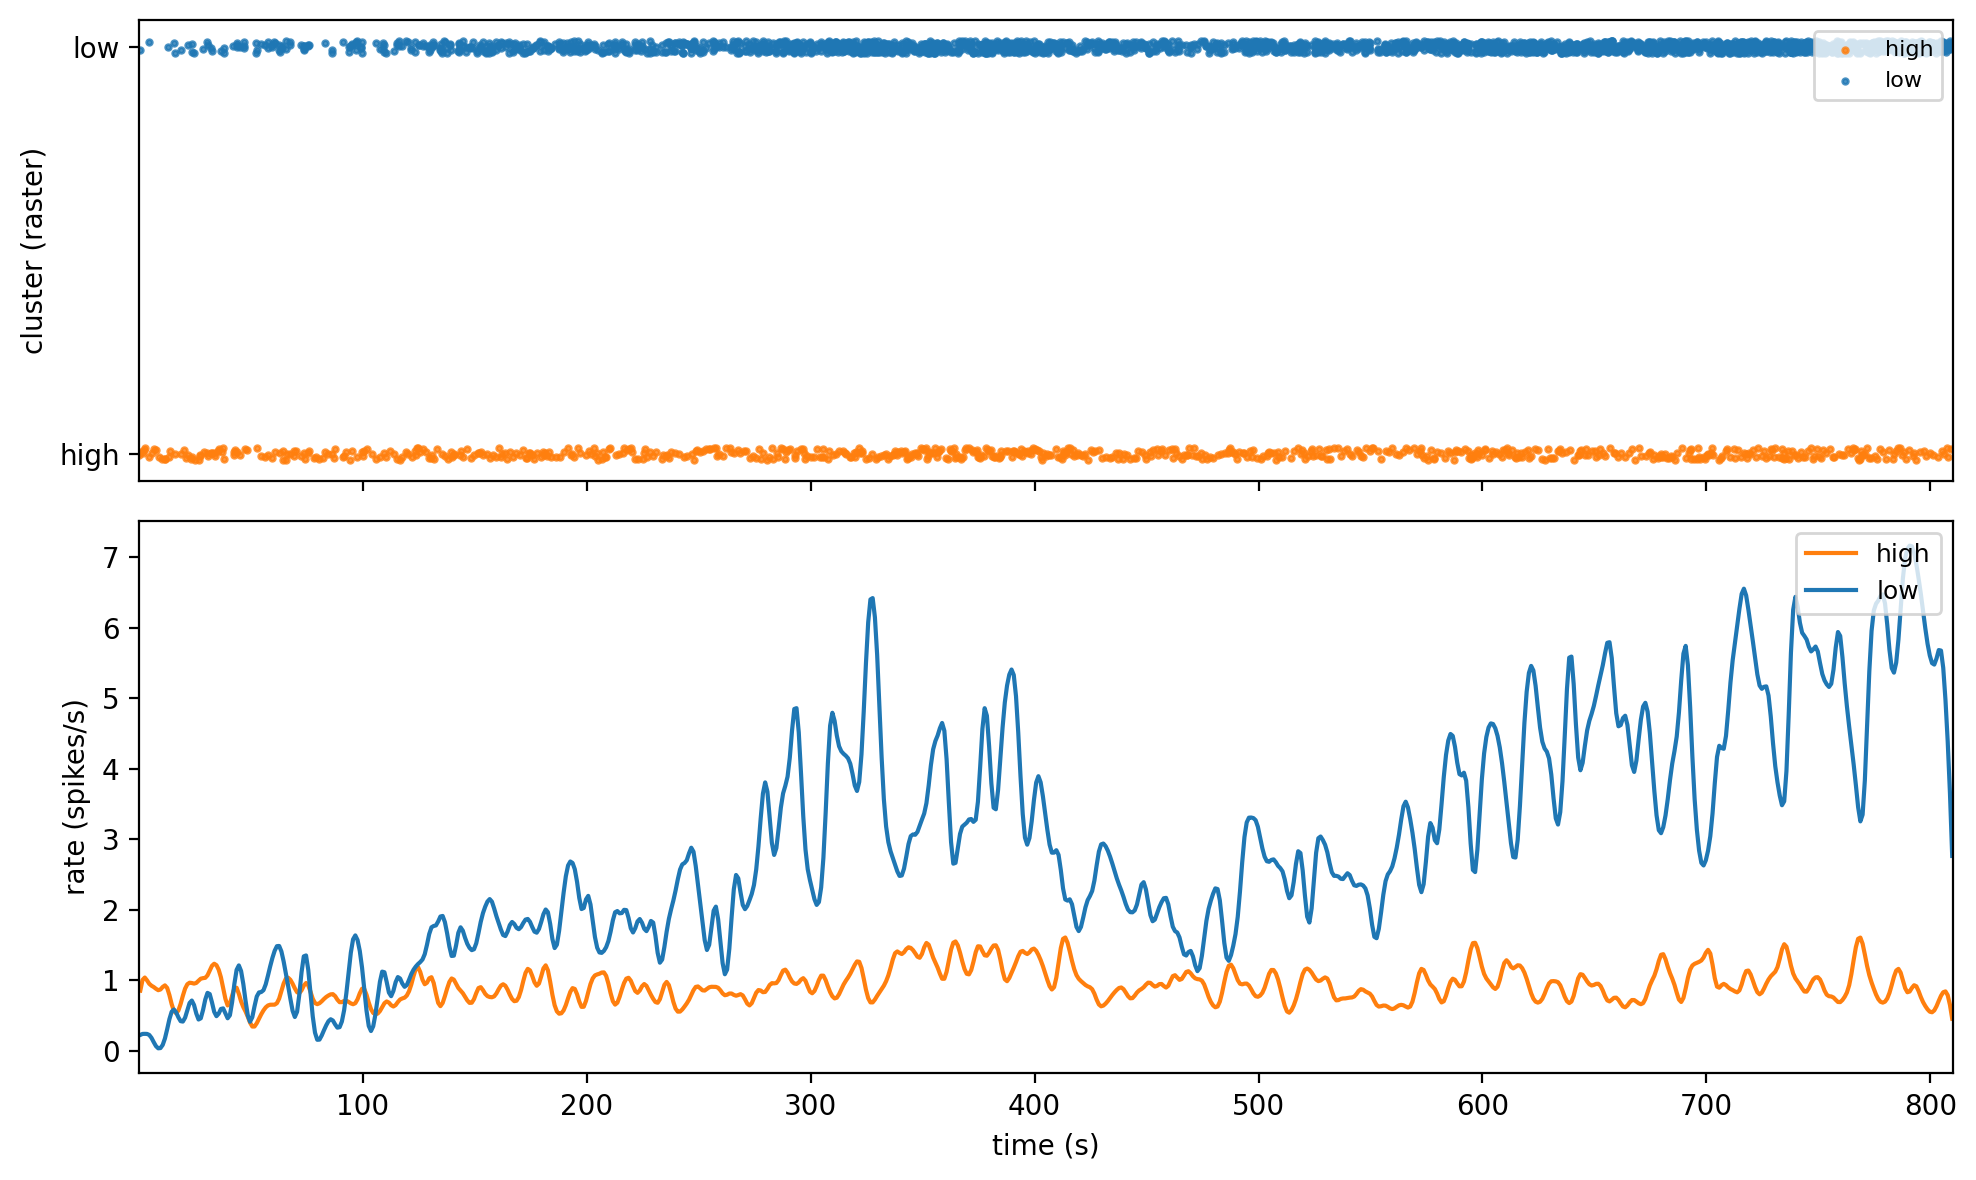


→ 3. Computing cluster transition matrix


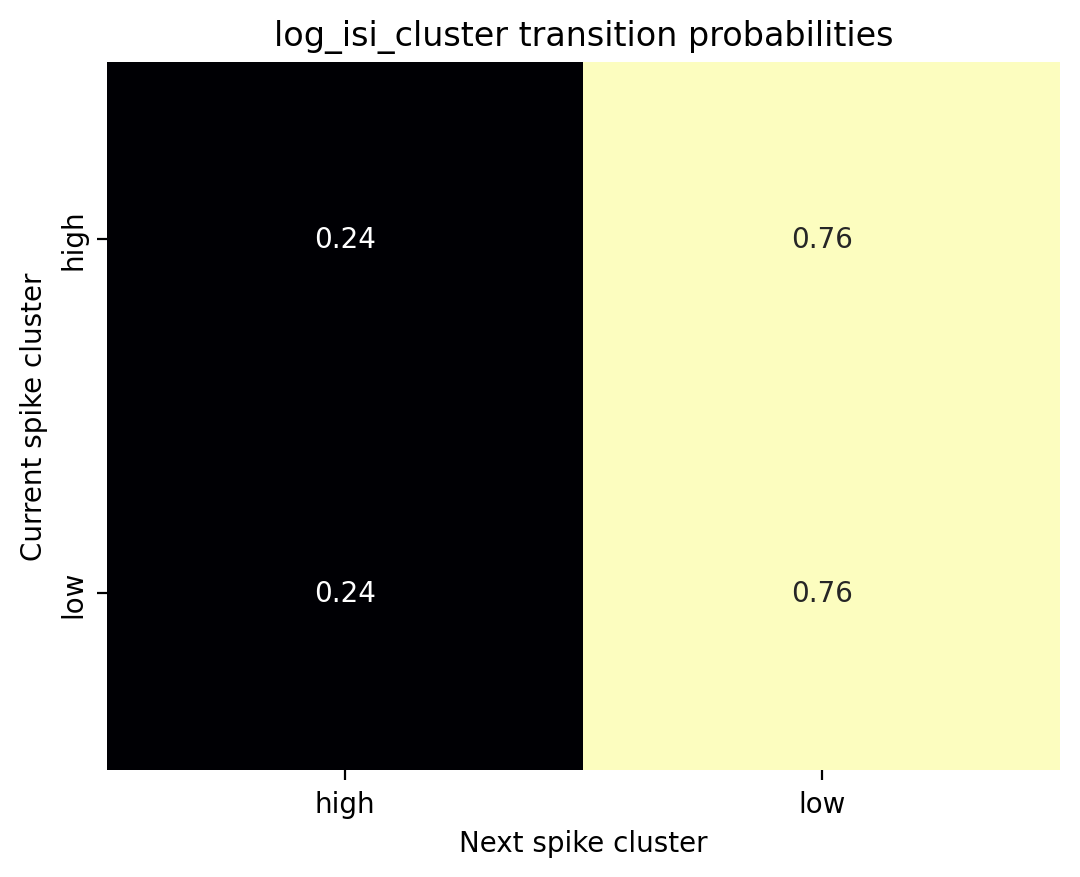


→ 4. Visualizing feature distributions by cluster


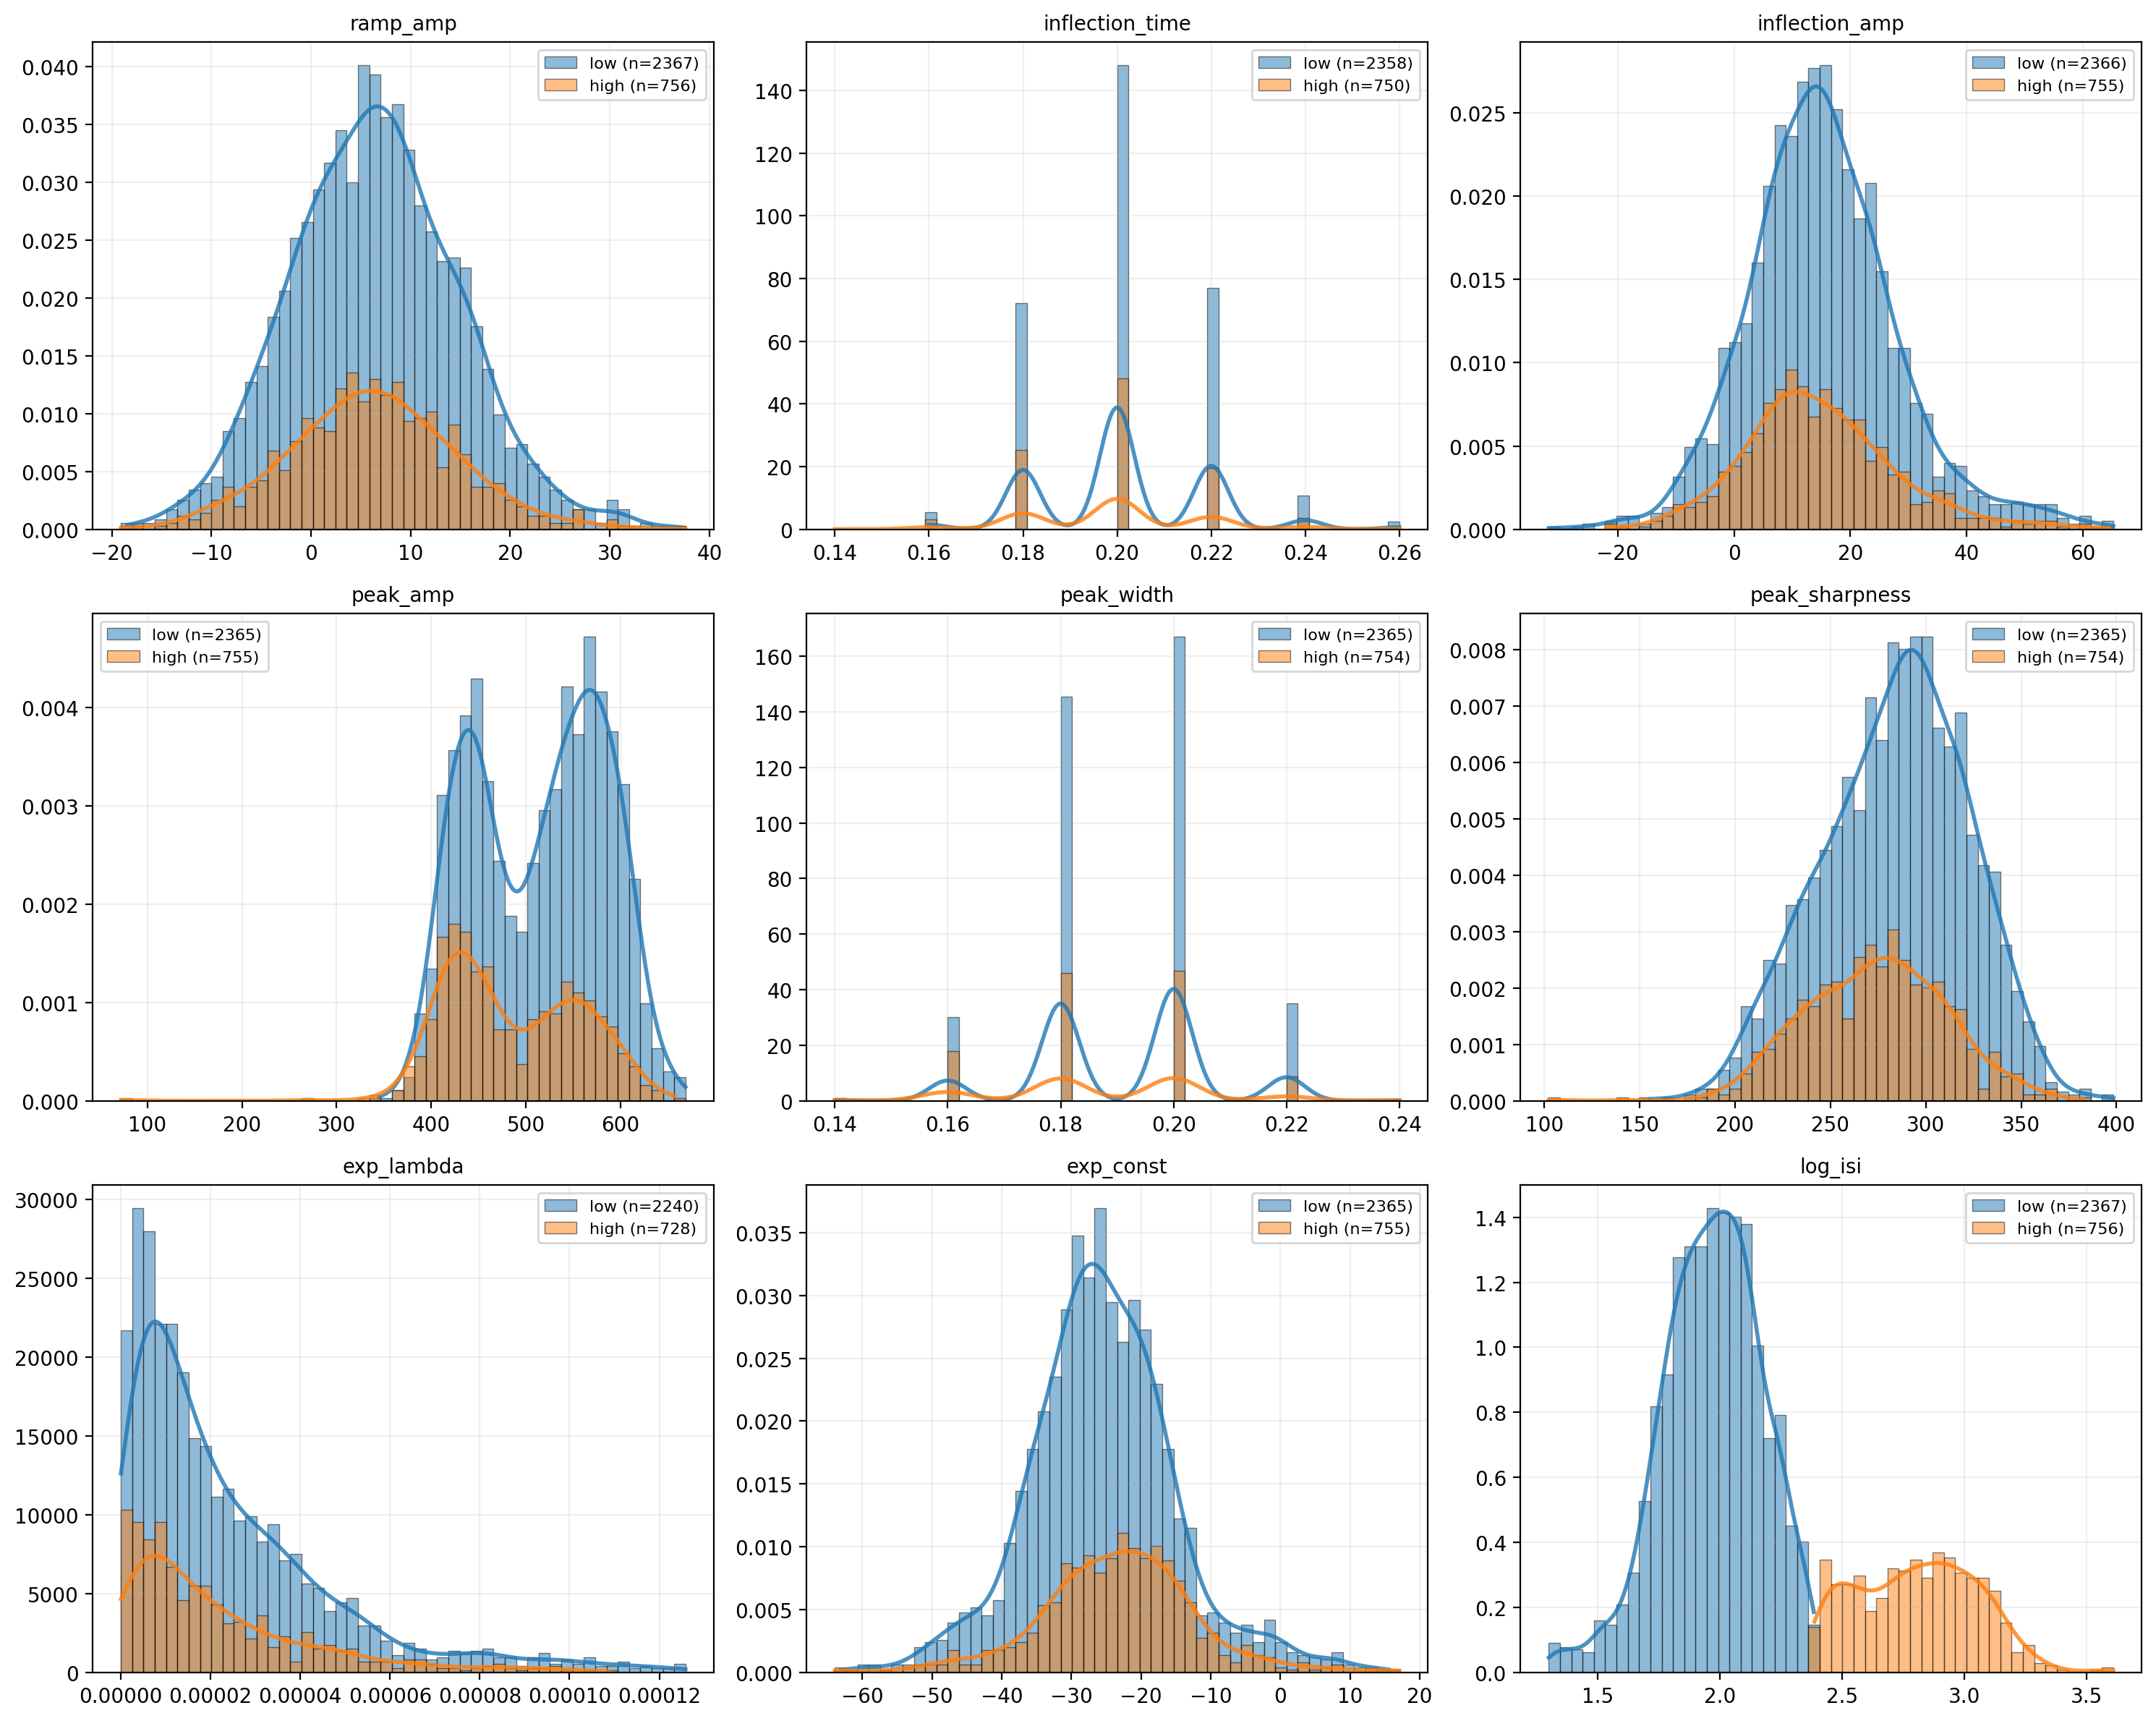


→ 5. Statistical analysis for: log_isi
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.738
Interpretation: Very Large


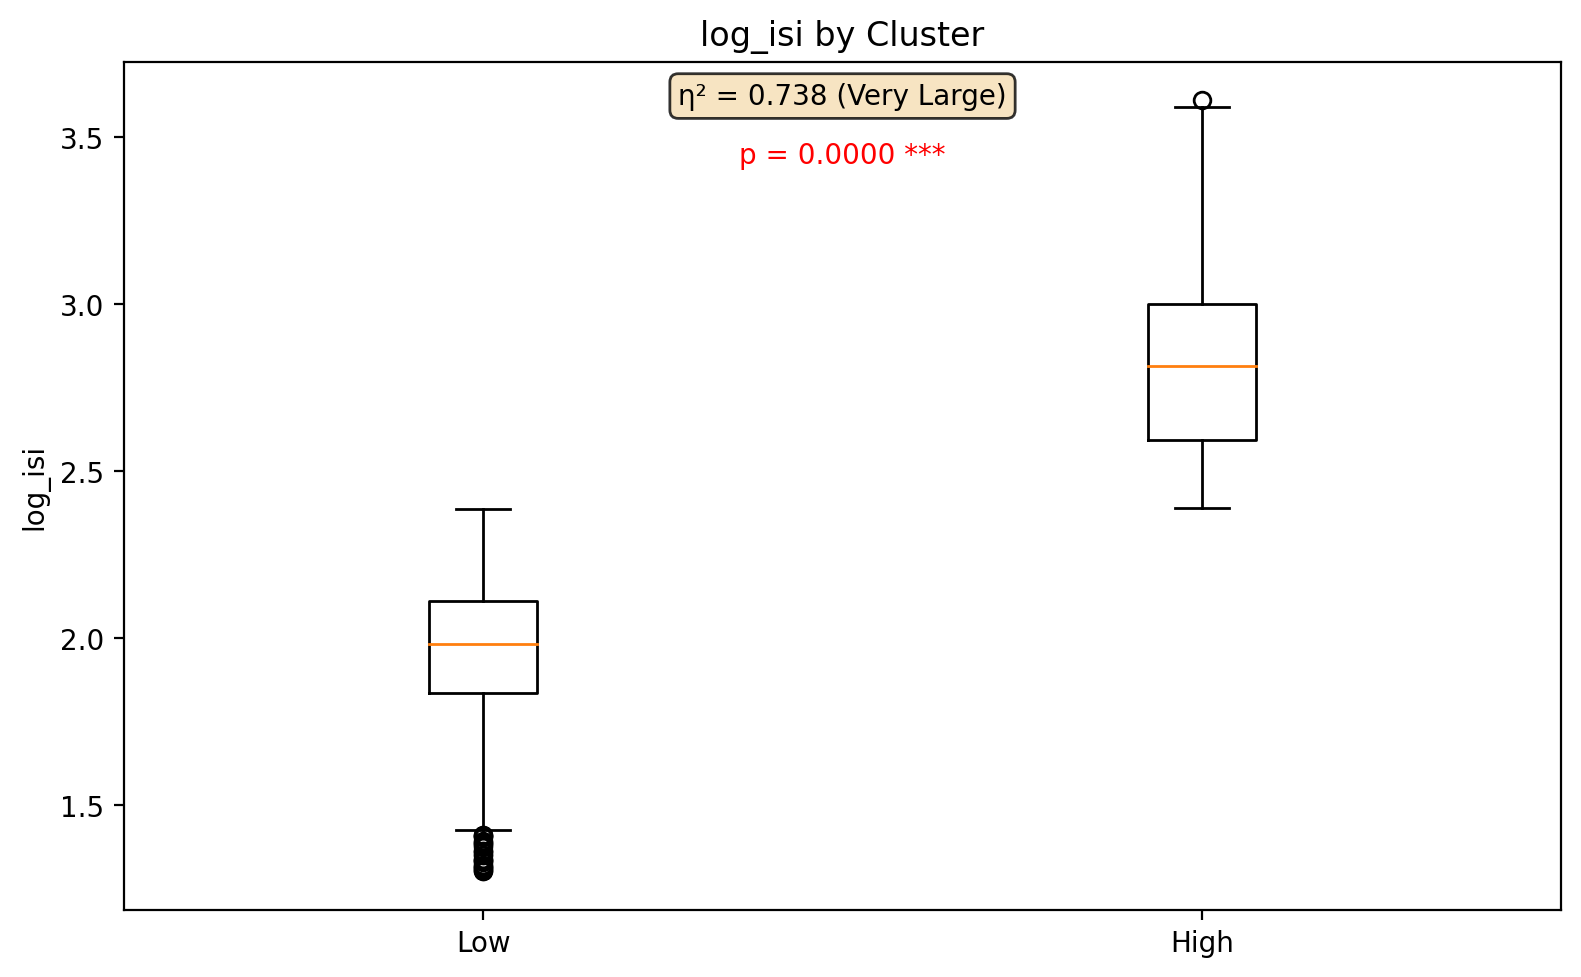


===== REPORT COMPLETE =====


===== CLUSTER REPORT: spk_times_ms_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster

→ 1.5 Average waveforms with visual RMSE


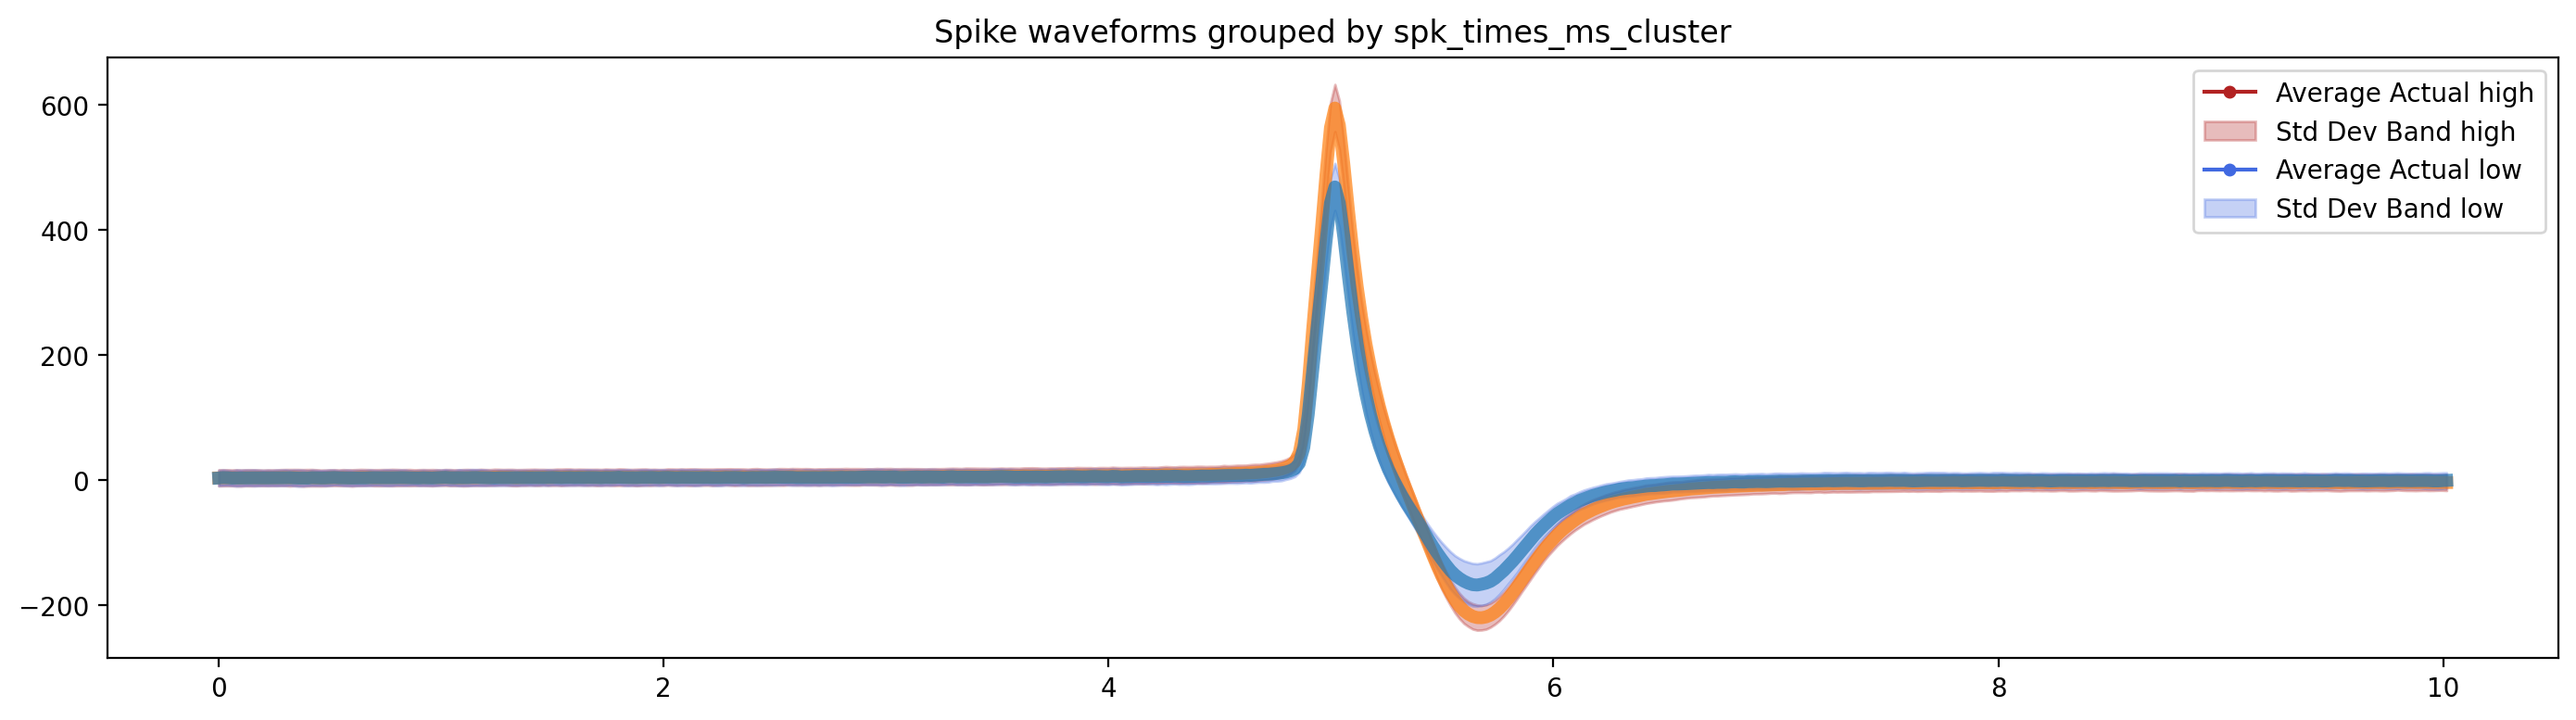

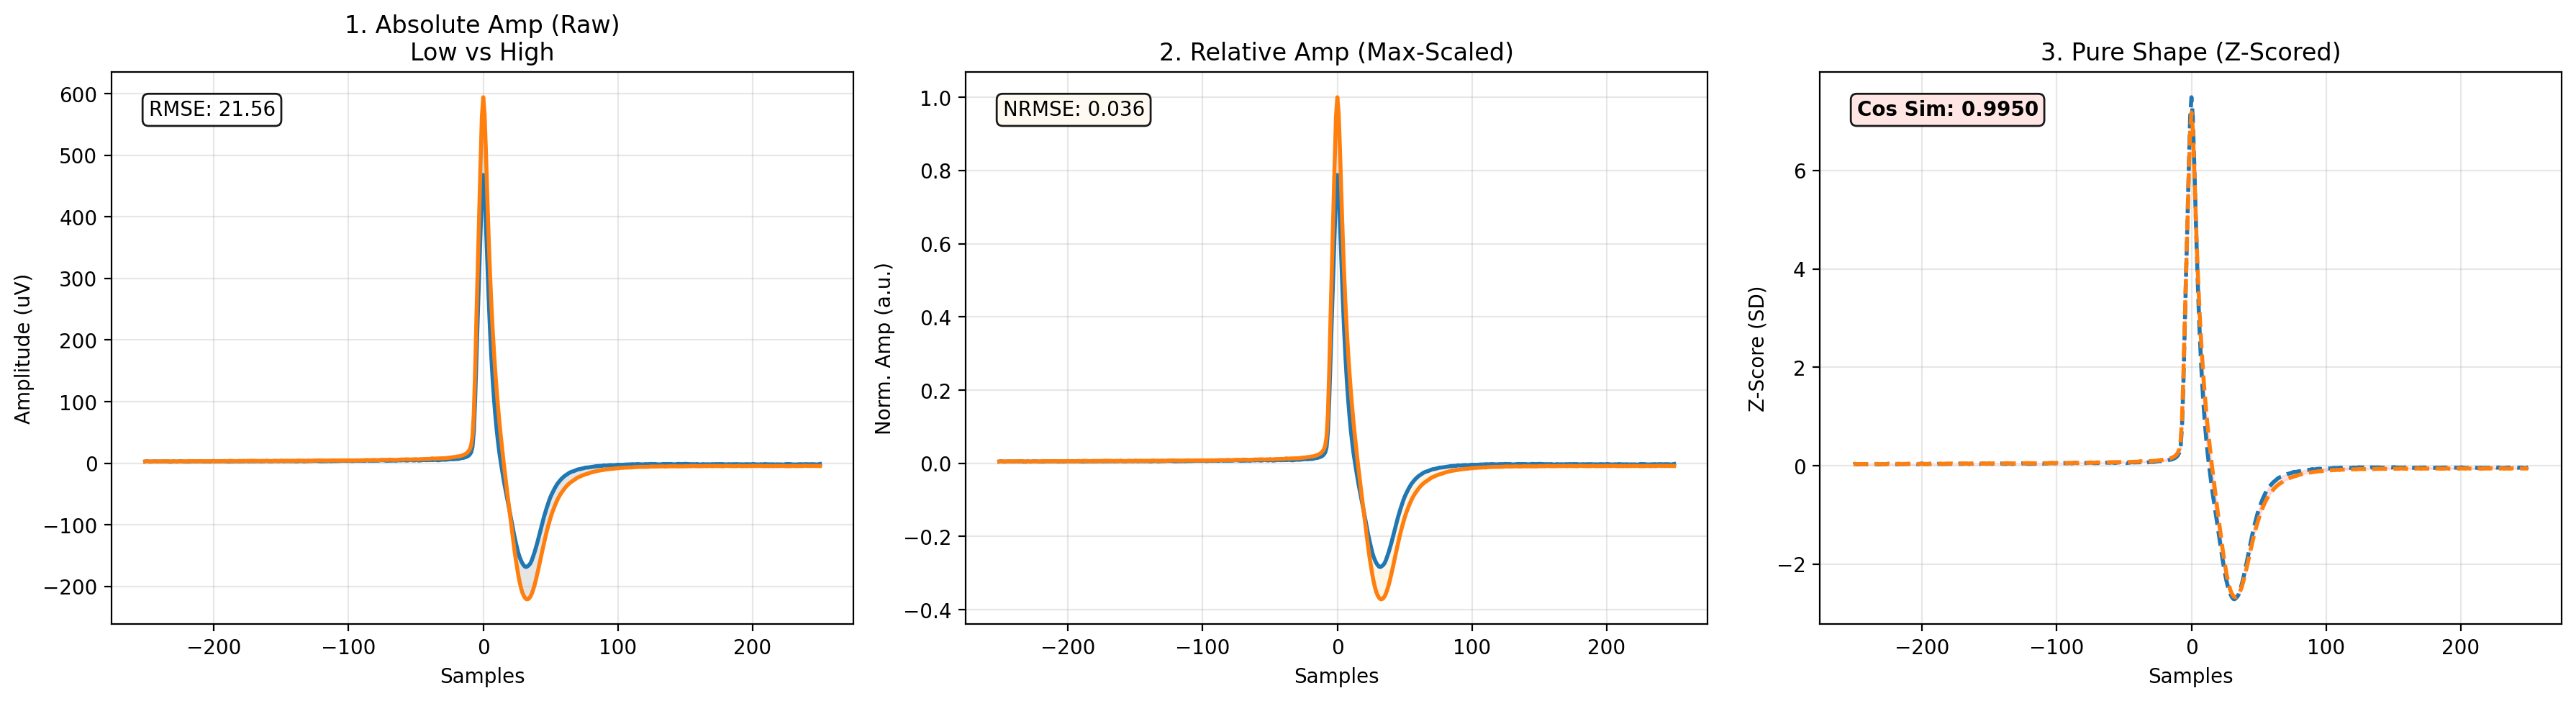


→ 2. Plotting cluster proportions over time


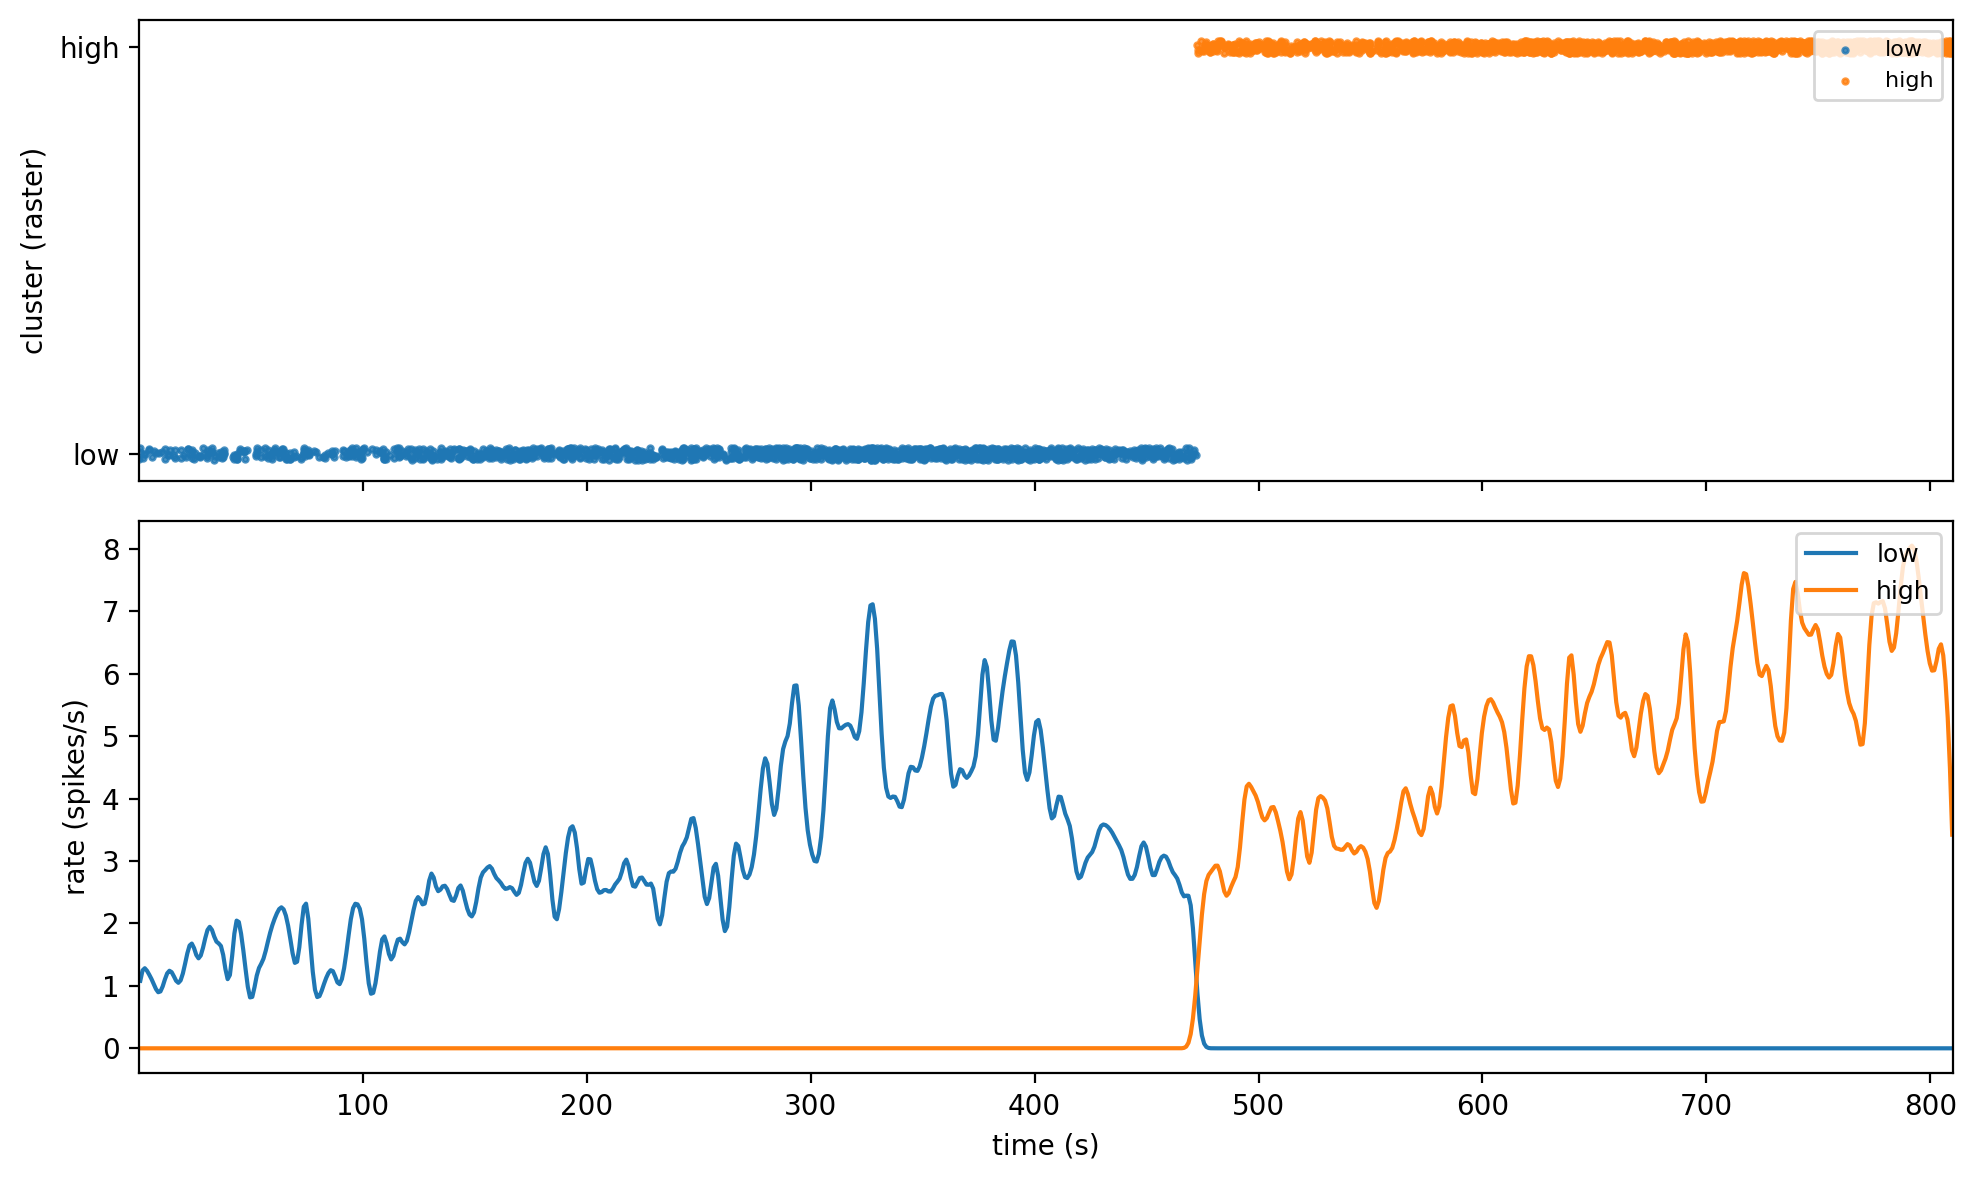


→ 3. Computing cluster transition matrix


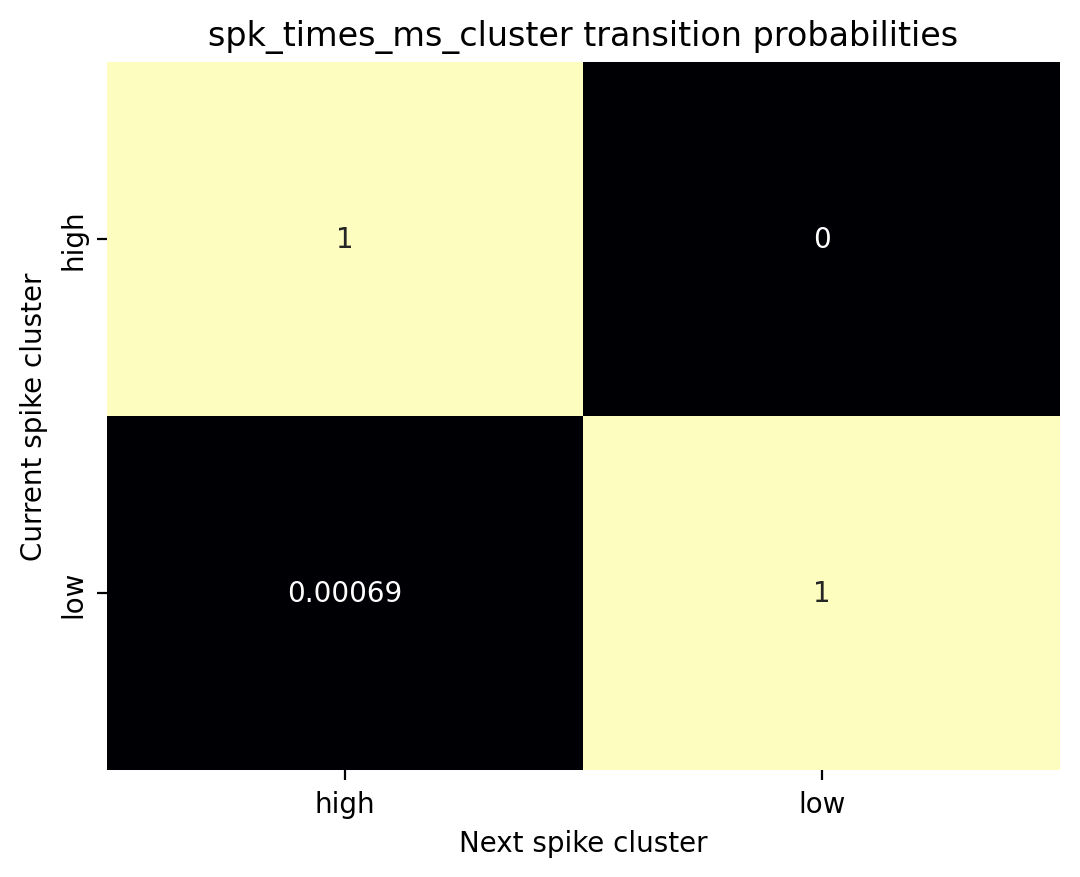


→ 4. Visualizing feature distributions by cluster


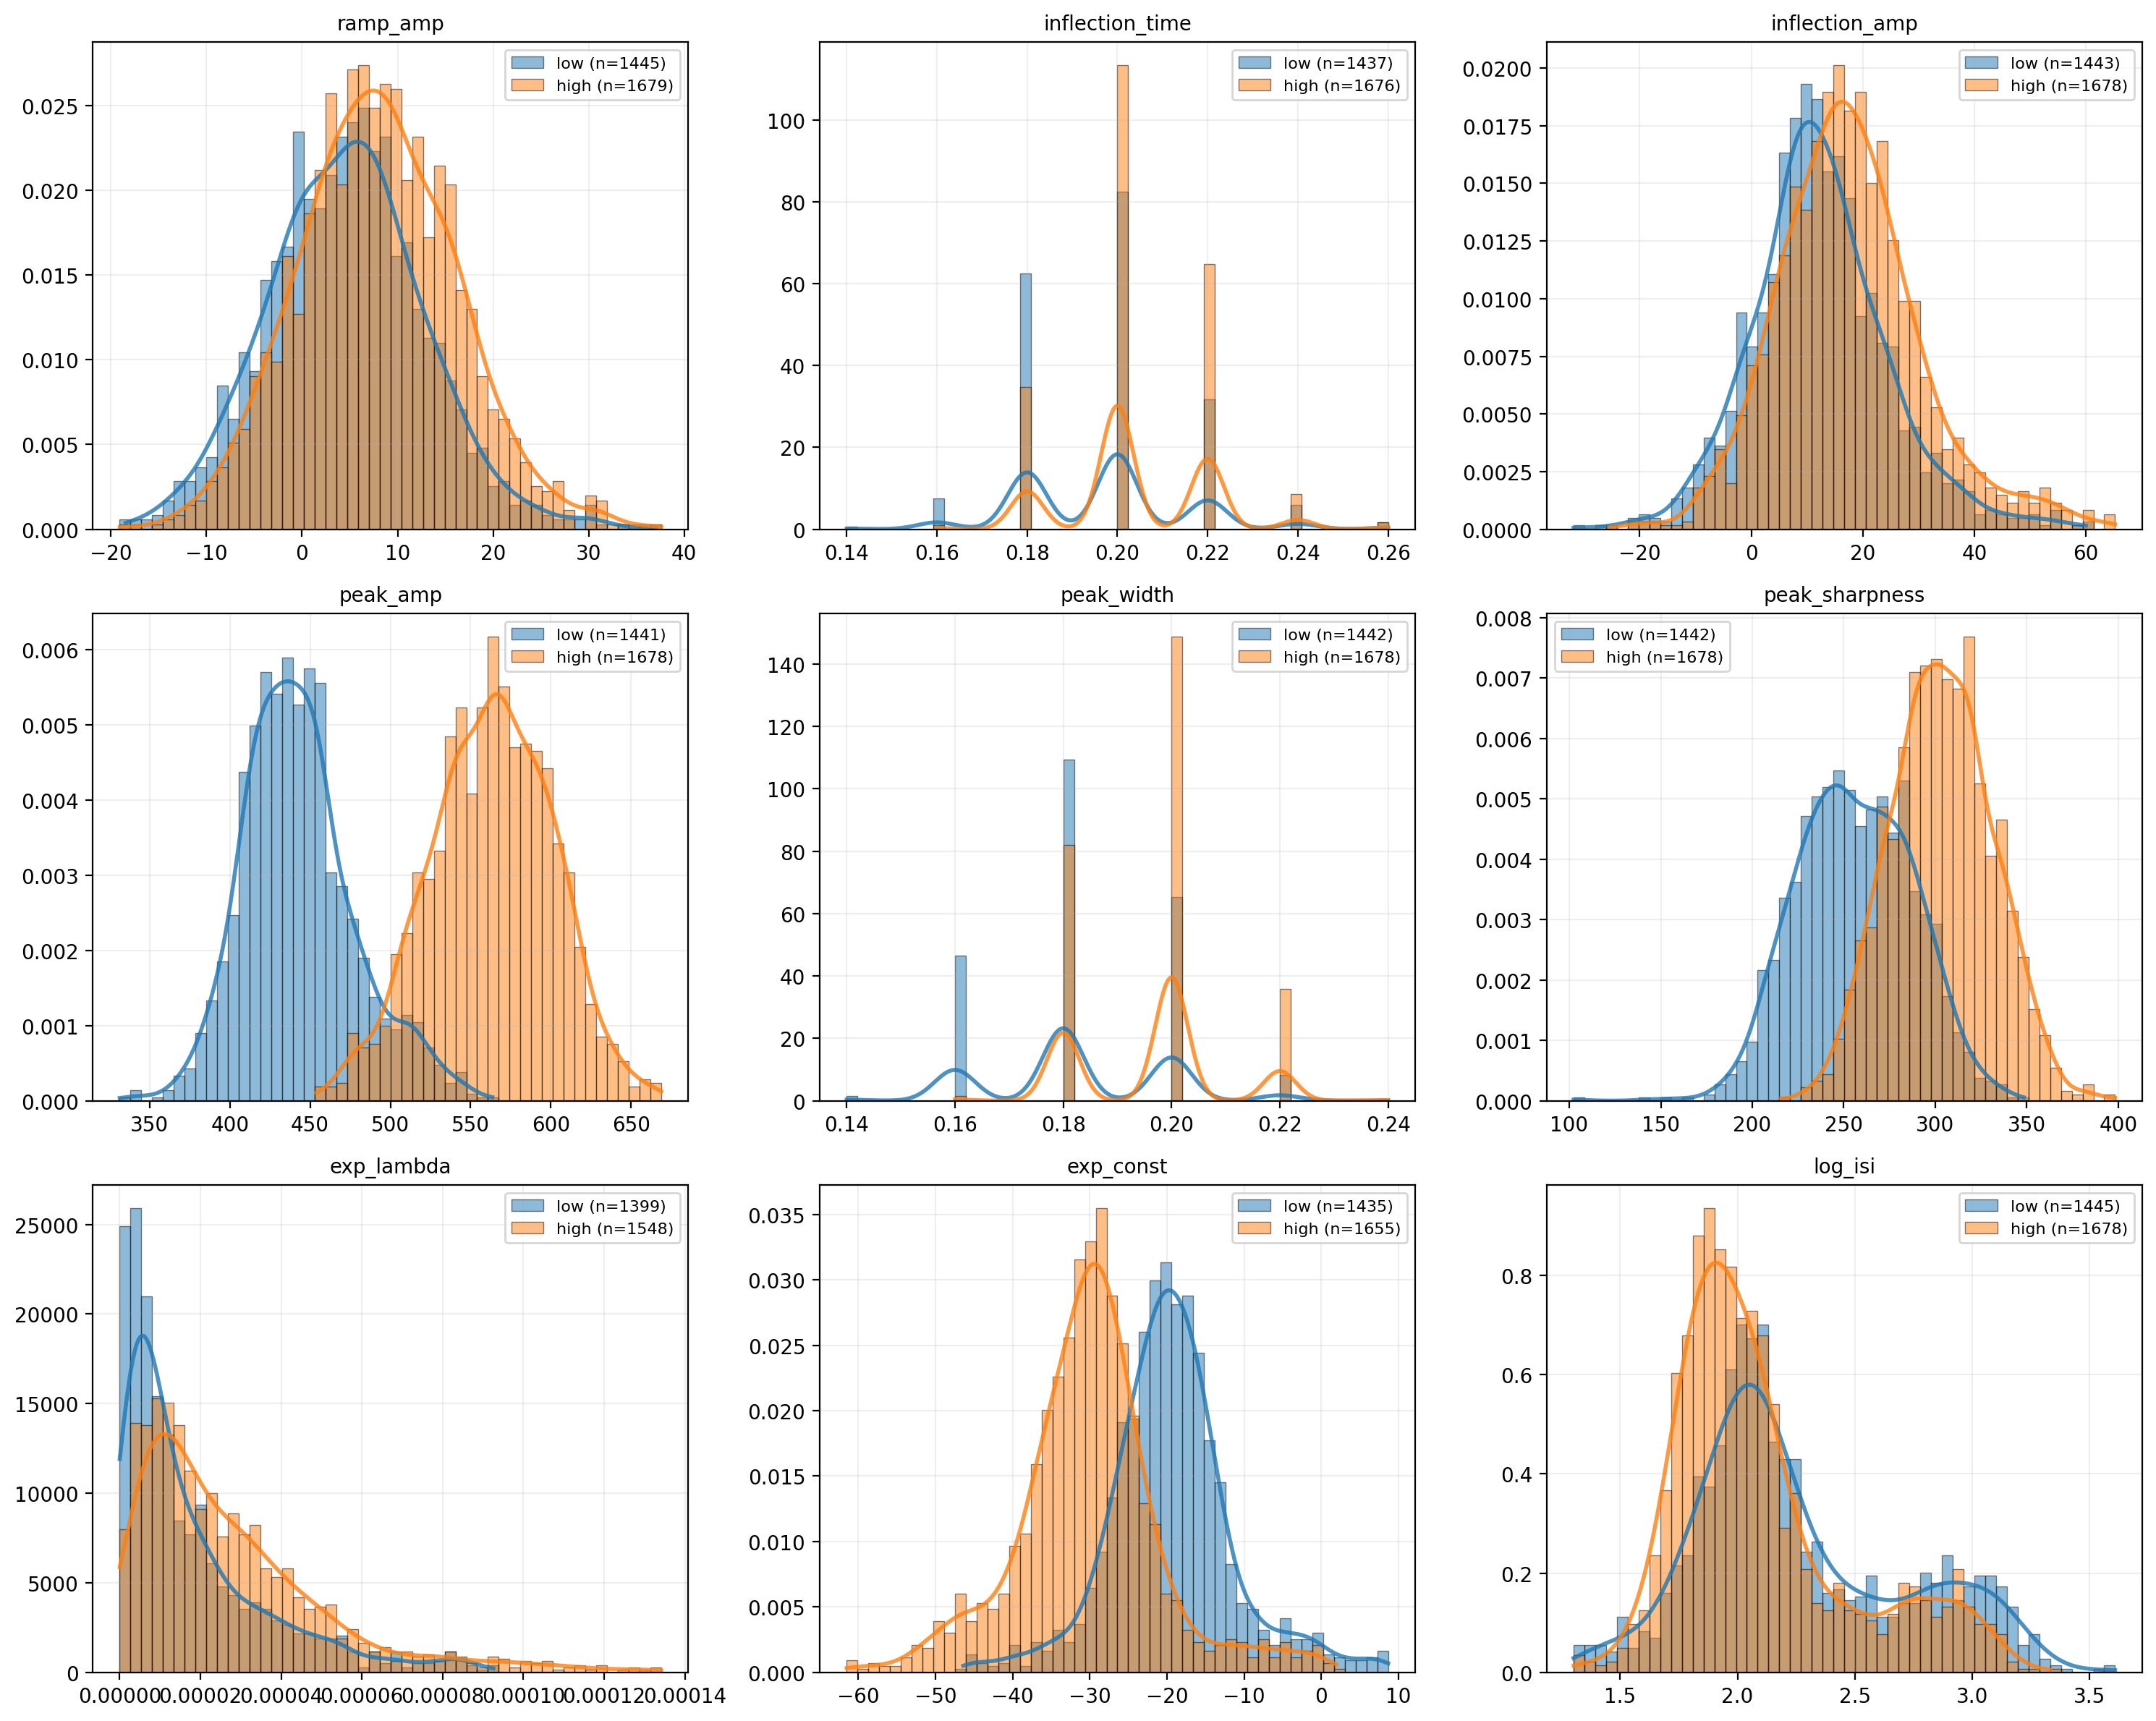


→ 5. Statistical analysis for: spk_times_ms
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.764
Interpretation: Very Large


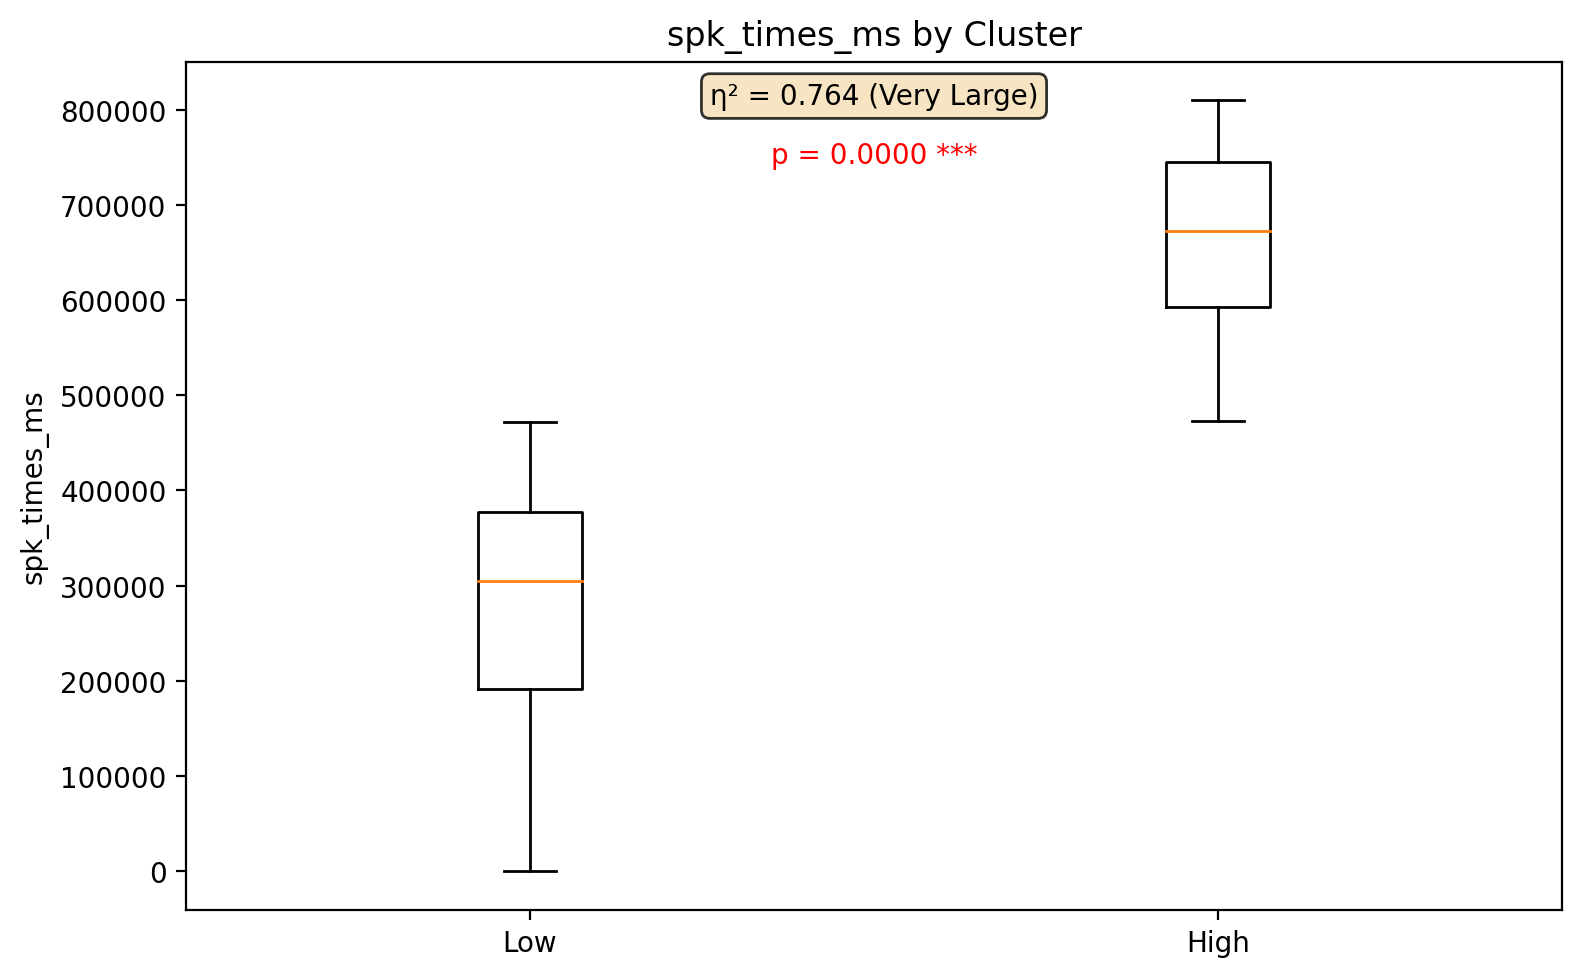


===== REPORT COMPLETE =====



In [20]:
all_reports = []

# Filter columns first to ensure the index is continuous
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # Pass 'i' as the cluster_group_id
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    all_reports.append(row_df)

# Final Master DataFrame
master_report_df = pd.concat(all_reports, ignore_index=True)

In [21]:
#export cluster info df 

with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/c36_df_clusters.pkl', 'wb') as file:
    pickle.dump(master_report_df, file)